# Repeat Baby Shopper — Deep-Dive Behavioral Analysis
### Built on Phase 1 Profile · Repeat Shoppers Only (>1 visit in 12M)

**Scope:** Filter the Phase 1 master profile to repeat shoppers, engineer additional
behavioral features, cluster into personas, build persona cards, and derive
actionable business recommendations.

**Pipeline:**
1. Load Phase 1 outputs & filter to repeat shoppers
2. Feature engineering (7 behavioral dimensions)
3. K-Means clustering with elbow + silhouette selection
4. Persona cards — statistics + distinguishing traits
5. Visualisations — radar, boxplots, PCA scatter
6. Strategic business recommendations


---
## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# ── Visual theme ───────────────────────────────────────────────────────────────
PALETTE  = ['#2C7BB6','#D7191C','#1A9641','#FDAE61','#762A83','#F46D43']
sns.set_theme(style='whitegrid', palette=PALETTE)
plt.rcParams.update({'figure.dpi':130,'axes.titlesize':12,
                     'axes.titleweight':'bold','figure.titlesize':13})
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)

RANDOM_STATE = 42
print("Setup complete.")


Setup complete.


---
## 2. Load Phase 1 Outputs & Filter to Repeat Shoppers

In [2]:
# ── 2.1 Load the master profile and monthly panel from Phase 1 ────────────────
profile = pd.read_parquet('baby_shopper_profiles_phase1.parquet')
panel   = pd.read_parquet('baby_shopper_panel_monthly.parquet')

print(f"Full profile  : {profile.shape[0]:,} customers, {profile.shape[1]} features")
print(f"Monthly panel : {panel.shape[0]:,} rows")
print(f"\nShopper type distribution:")
print(profile['shopper_type'].value_counts())


Full profile  : 1,483,837 customers, 70 features
Monthly panel : 17,806,044 rows

Shopper type distribution:
shopper_type
One-Time    854617
Repeat      629220
Name: count, dtype: int64


In [3]:
# ── 2.2 Filter: repeat shoppers = more than 1 visit in the 12-month window ────
#
# Definition: total_transactions_12m > 1
# This maps exactly to the notebook's 'Repeat' shopper_type flag, but we use
# the raw count so the threshold is transparent and auditable.

repeat = profile[profile['total_transactions_12m'] > 1].copy().reset_index(drop=True)
repeat_panel = panel[panel['customer_id'].isin(repeat['customer_id'])].copy()

n_repeat = len(repeat)
n_total  = len(profile)
print(f"Repeat shoppers  : {n_repeat:,} ({n_repeat/n_total*100:.1f}% of all shoppers)")
print(f"One-time shoppers: {n_total - n_repeat:,} ({(n_total-n_repeat)/n_total*100:.1f}%) — excluded")
print(f"\nRepeat shopper panel rows: {len(repeat_panel):,}")

# Quick sanity check
print(f"\nMin transactions in repeat set: {repeat['total_transactions_12m'].min()}")
print(f"Max transactions in repeat set: {repeat['total_transactions_12m'].max()}")


Repeat shoppers  : 991,443 (66.8% of all shoppers)
One-time shoppers: 492,394 (33.2%) — excluded

Repeat shopper panel rows: 11,897,316

Min transactions in repeat set: 2.0
Max transactions in repeat set: 410.0


In [4]:
# ── 2.3 Snapshot of repeat shopper base ──────────────────────────────────────
print("=== Repeat Shopper Quick Summary ===")
summary_cols = ['total_transactions_12m','total_spend_12m','avg_gap_days',
                'activity_span_days','days_since_last_purchase','engagement_density']
repeat[summary_cols].describe().T[['mean','std','min','25%','50%','75%','max']].round(2)


=== Repeat Shopper Quick Summary ===


,mean,std,min,25%,50%,75%,max
total_transactions_12m,7.230,9.760,2.000,2.000,4.000,8.000,410.000
total_spend_12m,4694.600,12762.640,38.000,1037.000,2016.000,4622.750,6088537.000
avg_gap_days,82.550,69.950,1.000,33.000,61.400,110.000,363.000
activity_span_days,110.110,118.970,0.000,0.000,65.000,212.000,364.000
days_since_last_purchase,106.940,105.340,0.000,16.000,66.000,186.000,364.000
engagement_density,0.200,0.160,0.080,0.080,0.170,0.250,1.000


---
## 3. Feature Engineering

Seven behavioral features are engineered to represent each repeat shopper.
These are either computed fresh from the panel (where time-series structure is needed)
or derived from the Phase 1 profile.

| # | Feature | Dimension |
|---|---------|-----------|
| 1 | `avg_interpurchase_interval` | Cadence |
| 2 | `spend_per_visit` | Basket size |
| 3 | `monthly_spend_cv` | Spend volatility |
| 4 | `category_breadth_score` | Category exploration |
| 5 | `recency_score` | Engagement recency |
| 6 | `engagement_consistency` | Loyalty / habit strength |
| 7 | `spend_acceleration` | Spend trajectory (growing vs fading) |


In [5]:
# ── Feature 1: Average inter-purchase interval ────────────────────────────────
# Already in profile as avg_gap_days (computed at day level in Phase 1).
# Rename for clarity in this analysis.
repeat['avg_interpurchase_interval'] = repeat['avg_gap_days']

print("Feature 1 — avg_interpurchase_interval")
print(repeat['avg_interpurchase_interval'].describe().round(1))


Feature 1 — avg_interpurchase_interval
count   629220.000
mean        82.500
std         70.000
min          1.000
25%         33.000
50%         61.400
75%        110.000
max        363.000
Name: avg_interpurchase_interval, dtype: float64


In [6]:
# ── Feature 2: Spend per visit ────────────────────────────────────────────────
# avg_spend_per_visit from Phase 1 = mean monthly spend on active months.
# For repeat shoppers we also want a per-transaction view.
repeat['spend_per_visit'] = (
    repeat['total_spend_12m'] / repeat['total_transactions_12m']
)

print("Feature 2 — spend_per_visit")
print(repeat['spend_per_visit'].describe().round(2))


Feature 2 — spend_per_visit
count   991443.000
mean       624.550
std        881.010
min         19.000
25%        334.800
50%        481.800
75%        698.500
max     356571.750
Name: spend_per_visit, dtype: float64


In [7]:
# ── Feature 3: Monthly spend coefficient of variation (volatility) ────────────
# Measures how erratic spend is month to month.
# Computed on the panel (requires time-series, not in static profile).
# CV = std / mean across active months only.

# Keep only active months for each repeat customer
active_rep = repeat_panel[
    (repeat_panel['is_active'] == 1) &
    (repeat_panel['customer_id'].isin(repeat['customer_id']))
]

spend_cv = (
    active_rep.groupby('customer_id')['total_spend']
              .agg(spend_std='std', spend_mean='mean')
              .reset_index()
)
spend_cv['monthly_spend_cv'] = spend_cv['spend_std'] / spend_cv['spend_mean'].clip(lower=0.01)
spend_cv = spend_cv[['customer_id','monthly_spend_cv']]

repeat = repeat.merge(spend_cv, on='customer_id', how='left')
repeat['monthly_spend_cv'] = repeat['monthly_spend_cv'].fillna(0)

print("Feature 3 — monthly_spend_cv")
print(repeat['monthly_spend_cv'].describe().round(3))


Feature 3 — monthly_spend_cv
count   991443.000
mean         0.398
std          0.437
min          0.000
25%          0.000
50%          0.274
75%          0.731
max          3.100
Name: monthly_spend_cv, dtype: float64


In [8]:
# ── Feature 4: Category breadth score ────────────────────────────────────────
# Normalised 0-1: how many of the available subdepartments does the customer visit?
# Uses distinct_subdept_count from Phase 1.
max_subdepts = repeat['distinct_subdept_count'].max()
repeat['category_breadth_score'] = repeat['distinct_subdept_count'] / max_subdepts

print("Feature 4 — category_breadth_score (normalised)")
print(repeat['category_breadth_score'].describe().round(3))


Feature 4 — category_breadth_score (normalised)
count   991443.000
mean         0.141
std          0.100
min          0.045
25%          0.091
50%          0.091
75%          0.182
max          1.000
Name: category_breadth_score, dtype: float64


In [9]:
# ── Feature 5: Recency score (inverse recency) ────────────────────────────────
# Higher = more recently active.  Transforms days_since_last_purchase so that
# a higher value always means BETTER engagement (consistent direction with
# other features, which avoids confusion in cluster interpretation).
#
# Formula: recency_score = 1 - (days_since_last / max_days_since)
# Clipped to [0, 1].

max_recency = repeat['days_since_last_purchase'].quantile(0.99)
repeat['recency_score'] = (
    1 - repeat['days_since_last_purchase'].clip(upper=max_recency) / max_recency
).clip(lower=0)

print("Feature 5 — recency_score (1 = very recent, 0 = long lapsed)")
print(repeat['recency_score'].describe().round(3))


Feature 5 — recency_score (1 = very recent, 0 = long lapsed)
count   991443.000
mean         0.698
std          0.297
min          0.000
25%          0.475
50%          0.814
75%          0.955
max          1.000
Name: recency_score, dtype: float64


In [10]:
# ── Feature 6: Engagement consistency ────────────────────────────────────────
# How consistently does the customer shop month after month?
# Uses engagement_density from Phase 1 = active_months / total_months.
# Supplemented by the inverse of purchase_regularity_cv (lower CV = more regular).
#
# consistency = engagement_density * (1 / (1 + purchase_regularity_cv))
# This rewards both showing up frequently AND having a regular rhythm.

repeat['engagement_consistency'] = (
    repeat['engagement_density'] *
    (1 / (1 + repeat['purchase_regularity_cv'].fillna(1)))
)

print("Feature 6 — engagement_consistency")
print(repeat['engagement_consistency'].describe().round(3))


Feature 6 — engagement_consistency
count   991443.000
mean         0.112
std          0.100
min          0.031
25%          0.042
50%          0.083
75%          0.145
max          0.817
Name: engagement_consistency, dtype: float64


In [11]:
# ── Feature 7: Spend acceleration ────────────────────────────────────────────
# Is this customer spending more or less over time?
# Computed as the slope of monthly spend across the observation window.
# A positive slope = growing customer. Negative = fading customer.
#
# Method: linear regression slope via least-squares on the panel.
# Vectorised using matrix operations — no apply/lambda.

rep_panel_sorted = (
    repeat_panel[repeat_panel['is_active'] == 1]
    .sort_values(['customer_id','year_month'])
    .copy()
)

# Month index (0, 1, 2 ...) within each customer's active months
rep_panel_sorted['month_idx'] = (
    rep_panel_sorted.groupby('customer_id').cumcount().astype(float)
)

# Compute OLS slope per customer using GroupBy aggregations (no apply)
# slope = (Σxy - n*x̄*ȳ) / (Σx² - n*x̄²)

# For 8M rows this operates on the already-filtered repeat_panel (~much smaller).
# Alternative without lambda: compute columns first, then aggregate.

rep_panel_sorted['x_times_y'] = rep_panel_sorted['month_idx'] * rep_panel_sorted['total_spend']
rep_panel_sorted['x_squared'] = rep_panel_sorted['month_idx'] ** 2


rep_panel_sorted['denom'] = rep_panel_sorted['x_squared'].groupby(rep_panel_sorted['customer_id']).transform('sum') - rep_panel_sorted.groupby('customer_id').size() * (rep_panel_sorted['month_idx'].groupby(rep_panel_sorted['customer_id']).transform('mean'))**2
rep_panel_sorted['numer'] = rep_panel_sorted['x_times_y'].groupby(rep_panel_sorted['customer_id']).transform('sum') - rep_panel_sorted.groupby('customer_id').size() * (rep_panel_sorted['month_idx'].groupby(rep_panel_sorted['customer_id']).transform('mean')) * (rep_panel_sorted['total_spend'].groupby(rep_panel_sorted['customer_id']).transform('mean'))
rep_panel_sorted['spend_acceleration'] = np.where(
    rep_panel_sorted['denom'].abs() < 1e-9, 0,
    rep_panel_sorted['numer'] / rep_panel_sorted['denom']
)

repeat = repeat.merge(rep_panel_sorted[['customer_id','spend_acceleration']], on='customer_id', how='left')
repeat['spend_acceleration'] = repeat['spend_acceleration'].fillna(0)

print("Feature 7 — spend_acceleration (positive = growing, negative = fading)")
print(repeat['spend_acceleration'].describe().round(2))


Feature 7 — spend_acceleration (positive = growing, negative = fading)
count   2422295.000
mean         47.820
std        1646.350
min     -785164.860
25%           0.000
50%           0.000
75%           0.000
max      445885.090
Name: spend_acceleration, dtype: float64


In [12]:
# ── Feature summary ───────────────────────────────────────────────────────────
ENG_FEATURES = [
    'avg_interpurchase_interval',
    'spend_per_visit',
    'monthly_spend_cv',
    'category_breadth_score',
    'recency_score',
    'engagement_consistency',
    'spend_acceleration',
]

print(f"Engineered features: {len(ENG_FEATURES)}")
print()
repeat[ENG_FEATURES].describe().T[['mean','std','min','50%','max']].round(3)


Engineered features: 7



,mean,std,min,50%,max
avg_interpurchase_interval,69.634,59.801,1.000,50.500,363.000
spend_per_visit,606.426,1040.593,19.000,484.816,356571.750
monthly_spend_cv,0.605,0.427,0.000,0.620,3.100
category_breadth_score,0.197,0.131,0.045,0.182,1.000
recency_score,0.789,0.248,0.000,0.910,1.000
engagement_consistency,0.190,0.140,0.031,0.156,0.817
spend_acceleration,47.816,1646.347,-785164.857,0.000,445885.090


---
## 4. Shopper Segmentation (Clustering)

**Algorithm: K-Means**
Chosen for interpretability and speed on this dataset size.
Features are scaled (StandardScaler) before clustering.
Optimal k selected by silhouette score; elbow curve provided for visual reference.

> For very large datasets (>500K customers) consider HDBSCAN for density-based
> clustering that handles noise and non-spherical clusters. K-Means is appropriate here.


In [13]:
# ── 4.1 Prepare feature matrix ────────────────────────────────────────────────
cluster_input = repeat[['customer_id'] + ENG_FEATURES].dropna(subset=ENG_FEATURES).copy()

# Clip outliers p1-p99 before scaling to prevent extreme values dominating distance
for col in ENG_FEATURES:
    lo, hi = cluster_input[col].quantile([0.01, 0.99])
    cluster_input[col] = cluster_input[col].clip(lo, hi)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(cluster_input[ENG_FEATURES])

print(f"Customers eligible for clustering: {len(cluster_input):,}")
print(f"Features: {ENG_FEATURES}")


Customers eligible for clustering: 2,060,072
Features: ['avg_interpurchase_interval', 'spend_per_visit', 'monthly_spend_cv', 'category_breadth_score', 'recency_score', 'engagement_consistency', 'spend_acceleration']


  k=2  inertia=11,108,737  silhouette=0.2359
  k=3  inertia=9,722,167  silhouette=0.2164
  k=4  inertia=8,413,197  silhouette=0.2281
  k=5  inertia=7,349,607  silhouette=0.2398
  k=6  inertia=6,398,044  silhouette=0.2296
  k=7  inertia=5,887,822  silhouette=0.2022
  k=8  inertia=5,536,094  silhouette=0.1875


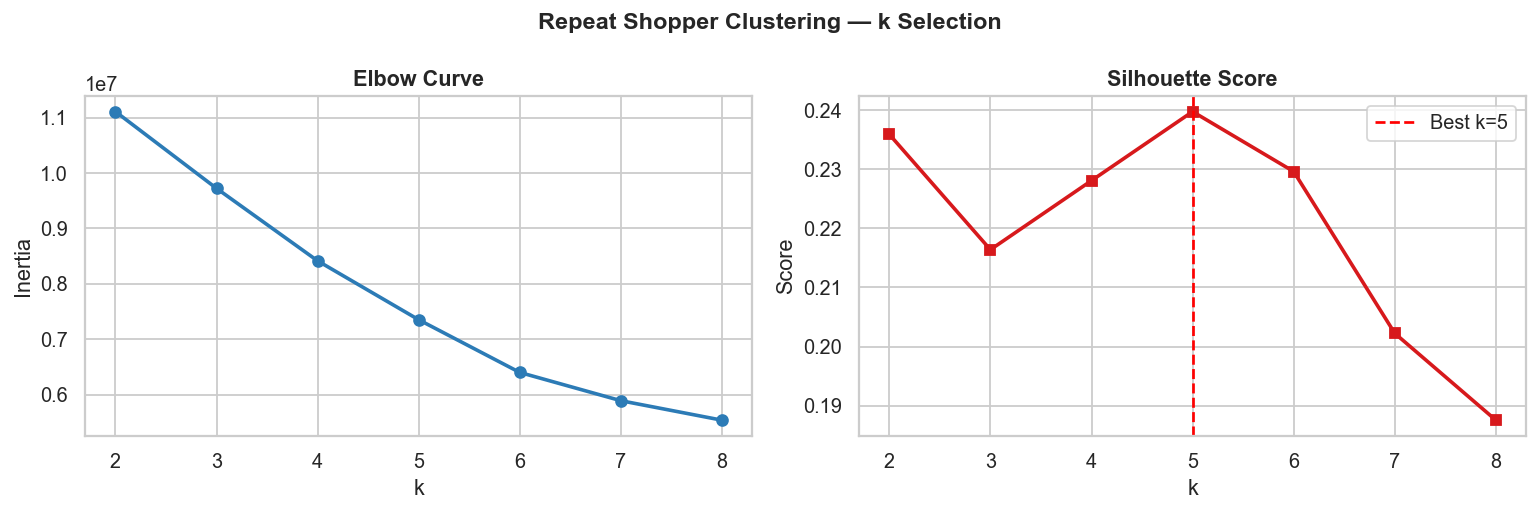


Statistically optimal k = 5


In [14]:
# ── 4.2 Elbow + Silhouette — choose optimal k ─────────────────────────────────
K_RANGE     = range(2, 9)
inertias    = []
silhouettes = []

for k in K_RANGE:
    km  = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(
        X_scaled, lbl,
        sample_size=min(5000, len(X_scaled)),
        random_state=RANDOM_STATE
    )
    silhouettes.append(sil)
    print(f"  k={k}  inertia={km.inertia_:,.0f}  silhouette={sil:.4f}")

best_k = list(K_RANGE)[np.argmax(silhouettes)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(K_RANGE), inertias,    'o-', color=PALETTE[0], linewidth=2)
ax1.set_title('Elbow Curve'); ax1.set_xlabel('k'); ax1.set_ylabel('Inertia')

ax2.plot(list(K_RANGE), silhouettes, 's-', color=PALETTE[1], linewidth=2)
ax2.axvline(best_k, color='red', linestyle='--', lw=1.5, label=f'Best k={best_k}')
ax2.set_title('Silhouette Score'); ax2.set_xlabel('k'); ax2.set_ylabel('Score')
ax2.legend()

plt.suptitle('Repeat Shopper Clustering — k Selection', fontweight='bold')
plt.tight_layout()
plt.savefig('RS_01_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nStatistically optimal k = {best_k}")


In [15]:
# ── 4.3 Fit final model ───────────────────────────────────────────────────────
# Define final K - using best_k from previous elbow/silhouette analysis
K_FINAL = best_k 

# Initialize and fit KMeans
km_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=20)

# Fit on scaled data and add to the input frame
cluster_labels = km_final.fit_predict(X_scaled)
cluster_input['cluster'] = cluster_labels

# ── SAFE MAPPING ────────────────────────────────────────────────────────────
# 1. Ensure cluster_input only has ONE row per customer_id
# We drop duplicates just in case some IDs were processed twice
unique_clusters = cluster_input[['customer_id', 'cluster']].drop_duplicates('customer_id')

# 2. Create the mapping series
cluster_map = unique_clusters.set_index('customer_id')['cluster']

# 3. Apply the map
# We use .astype('float32') first because if any IDs are missing, 
# 'int8' will crash on NaN values. We can convert to int later.
repeat['cluster'] = repeat['customer_id'].map(cluster_map)

# 4. Handle any shoppers not in the cluster (optional)
# If a shopper had only 1 visit, they won't be in the cluster_map
repeat['cluster'] = repeat['cluster'].fillna(-1).astype('int8')
# ── Cluster Diagnostics ─────────────────────────────────────────────────────
dist = repeat['cluster'].value_counts().sort_index()
total_shoppers = len(repeat)

print(f"✅ Model Fitted. K_FINAL = {K_FINAL}")
print("-" * 30)
print("Cluster Distribution (Repeat Shoppers):")
for c, n in dist.items():
    pct = (n / total_shoppers) * 100
    print(f"  Cluster {c:2}: {n:10,} shoppers ({pct:5.1f}%)")

✅ Model Fitted. K_FINAL = 5
------------------------------
Cluster Distribution (Repeat Shoppers):
  Cluster -1:    362,223 shoppers ( 15.0%)
  Cluster  0:    798,174 shoppers ( 33.0%)
  Cluster  1:     75,334 shoppers (  3.1%)
  Cluster  2:    130,831 shoppers (  5.4%)
  Cluster  3:    706,511 shoppers ( 29.2%)
  Cluster  4:    349,222 shoppers ( 14.4%)


In [16]:
# ── 4.4 Cluster centroids ─────────────────────────────────────────────────────
centroids = (
    repeat.dropna(subset=['cluster'])
          .groupby('cluster')[ENG_FEATURES]
          .median()
)
centroids['n_customers'] = repeat['cluster'].value_counts().sort_index()
centroids['pct']         = (centroids['n_customers'] / len(repeat) * 100).round(1)

print("=== Cluster Centroids (median) ===")
centroids.T.round(3)


=== Cluster Centroids (median) ===


cluster,-1,0,1,2,3,4
avg_interpurchase_interval,NaN,88.667,36.000,55.000,32.727,47.333
spend_per_visit,477.600,446.778,729.896,1501.373,488.147,424.361
monthly_spend_cv,0.000,0.560,0.788,1.151,0.806,0.560
category_breadth_score,0.091,0.136,0.318,0.227,0.318,0.136
recency_score,0.551,0.935,0.935,0.904,0.958,0.497
engagement_consistency,0.042,0.125,0.250,0.160,0.332,0.083
spend_acceleration,0.000,0.000,699.010,0.000,0.000,0.000
n_customers,362223.000,798174.000,75334.000,130831.000,706511.000,349222.000
pct,15.000,33.000,3.100,5.400,29.200,14.400


In [17]:
# ── 4.5 Name clusters from centroid profile ───────────────────────────────────
# Naming logic reads centroid values and applies priority-ordered heuristics.
# Review centroids above and rename PERSONA_NAMES dict as needed.

PERSONA_NAMES = {}

med_interval    = centroids['avg_interpurchase_interval'].median()
med_spend       = centroids['spend_per_visit'].median()
med_recency     = centroids['recency_score'].median()
med_consistency = centroids['engagement_consistency'].median()
med_accel       = centroids['spend_acceleration'].median()
med_cv          = centroids['monthly_spend_cv'].median()
med_breadth     = centroids['category_breadth_score'].median()

for c in sorted(repeat['cluster'].dropna().unique()):
    c = int(c)
    interval    = centroids.loc[c, 'avg_interpurchase_interval']
    spend       = centroids.loc[c, 'spend_per_visit']
    recency     = centroids.loc[c, 'recency_score']
    consistency = centroids.loc[c, 'engagement_consistency']
    accel       = centroids.loc[c, 'spend_acceleration']
    cv          = centroids.loc[c, 'monthly_spend_cv']
    breadth     = centroids.loc[c, 'category_breadth_score']

    if recency < med_recency * 0.6 and accel < 0:
        name = 'Fading High-Loyalty'
    elif consistency > med_consistency * 1.3 and interval < med_interval:
        name = 'Habitual Regulars'
    elif spend > med_spend * 1.4 and interval > med_interval * 1.2:
        name = 'Infrequent High-Spenders'
    elif accel > med_accel and consistency > med_consistency:
        name = 'Rising Engagers'
    elif breadth > med_breadth * 1.2 and consistency > med_consistency:
        name = 'Broad Explorers'
    elif cv > med_cv * 1.3:
        name = 'Volatile Shoppers'
    else:
        name = 'Moderate Occasionals'

    PERSONA_NAMES[c] = name
    print(f"Cluster {c} ({centroids.loc[c,'pct']:.1f}%) → '{name}'")

repeat['persona'] = repeat['cluster'].map(PERSONA_NAMES)


Cluster -1 (15.0%) → 'Moderate Occasionals'
Cluster 0 (33.0%) → 'Moderate Occasionals'
Cluster 1 (3.1%) → 'Habitual Regulars'
Cluster 2 (5.4%) → 'Broad Explorers'
Cluster 3 (29.2%) → 'Habitual Regulars'
Cluster 4 (14.4%) → 'Moderate Occasionals'


---
## 5. Persona Cards

For each cluster: key statistics, distinguishing traits vs the overall repeat shopper average, and top categories.


In [18]:
# ── 5.1 Overall repeat shopper baseline (for comparison) ─────────────────────
baseline = repeat[ENG_FEATURES + ['total_spend_12m','total_transactions_12m',
                                   'activity_span_days']].median()
print("=== Repeat Shopper Baseline (median) ===")
baseline.round(2)


=== Repeat Shopper Baseline (median) ===


avg_interpurchase_interval     50.500
spend_per_visit               484.820
monthly_spend_cv                0.620
category_breadth_score          0.180
recency_score                   0.910
engagement_consistency          0.160
spend_acceleration              0.000
total_spend_12m              3651.250
total_transactions_12m          7.000
activity_span_days            203.000
dtype: float64

In [19]:
# ── 5.2 Load raw transaction data for top-category lookup ─────────────────────
# Top subdepartments per cluster from share-of-wallet columns in profile.
sow_cols = [c for c in repeat.columns if c.startswith('sow__')]

def top_categories(df_cluster, n=3):
    if not sow_cols:
        return 'N/A'
    means = df_cluster[sow_cols].mean().sort_values(ascending=False).head(n)
    return ', '.join([c.replace('sow__','').replace('_',' ').title() for c in means.index])

persona_order = list(PERSONA_NAMES.values())


In [20]:
# ── 5.3 Print persona cards ───────────────────────────────────────────────────
CARD_METRICS = {
    'Customers':             ('cluster', 'count'),
    'Median Spend (12M)':    ('total_spend_12m', 'median'),
    'Median Transactions':   ('total_transactions_12m', 'median'),
    'Avg Gap (days)':        ('avg_interpurchase_interval', 'median'),
    'Spend/Visit':           ('spend_per_visit', 'median'),
    'Spend Volatility (CV)': ('monthly_spend_cv', 'median'),
    'Category Breadth':      ('category_breadth_score', 'median'),
    'Recency Score':         ('recency_score', 'median'),
    'Engagement Consistency':('engagement_consistency', 'median'),
    'Spend Acceleration':    ('spend_acceleration', 'median'),
    'Activity Span (days)':  ('activity_span_days', 'median'),
}

for persona_name in PERSONA_NAMES.values():
    grp = repeat[repeat['persona'] == persona_name]
    if grp.empty:
        continue

    print("=" * 65)
    print(f"  PERSONA: {persona_name.upper()}")
    print("=" * 65)

    for label, (col, agg) in CARD_METRICS.items():
        if col == 'cluster':
            val = len(grp)
            pct = len(grp) / len(repeat) * 100
            print(f"  {'Customers':30s}: {val:,} ({pct:.1f}% of repeat shoppers)")
        elif col in grp.columns:
            val = grp[col].median() if agg == 'median' else grp[col].agg(agg)
            base_val = baseline.get(col, np.nan)
            if pd.notna(base_val) and base_val != 0:
                diff_pct = (val - base_val) / abs(base_val) * 100
                direction = '▲' if diff_pct > 5 else ('▼' if diff_pct < -5 else '≈')
                print(f"  {label:30s}: {val:>10.2f}  {direction} {abs(diff_pct):.0f}% vs avg")
            else:
                print(f"  {label:30s}: {val:>10.2f}")

    if sow_cols:
        top_cats = top_categories(grp)
        print(f"  {'Top Categories':30s}: {top_cats}")

    # Distinguishing traits — features where this cluster deviates most from avg
    # Distinguishing traits — vectorised: build Series, take abs, nlargest
    grp_medians  = grp[ENG_FEATURES].median()
    base_vals    = baseline[ENG_FEATURES]
    rel_dev      = (grp_medians - base_vals) / base_vals.abs().clip(lower=1e-9)
    top_devs     = rel_dev.abs().nlargest(3)
    print(f"  {'Top distinguishing traits':30s}:")
    for feat in top_devs.index:
        dev = rel_dev[feat]
        direction = 'much higher' if dev > 0 else 'much lower'
        print(f"    → {feat}: {direction} ({dev*100:+.0f}% vs avg)")
    print()


  PERSONA: MODERATE OCCASIONALS
  Customers                     : 1,509,619 (62.3% of repeat shoppers)
  Median Spend (12M)            :    1967.00  ▼ 46% vs avg
  Median Transactions           :       4.00  ▼ 43% vs avg
  Avg Gap (days)                :      74.50  ▲ 48% vs avg
  Spend/Visit                   :     448.83  ▼ 7% vs avg
  Spend Volatility (CV)         :       0.42  ▼ 32% vs avg
  Category Breadth              :       0.09  ▼ 50% vs avg
  Recency Score                 :       0.82  ▼ 9% vs avg
  Engagement Consistency        :       0.08  ▼ 47% vs avg
  Spend Acceleration            :       0.00
  Activity Span (days)          :     122.00  ▼ 40% vs avg
  Top Categories                : Toiletries, Newborn Essential 0-12 Mos, Nursing & Feeding
  Top distinguishing traits     :
    → category_breadth_score: much lower (-50% vs avg)
    → avg_interpurchase_interval: much higher (+48% vs avg)
    → engagement_consistency: much lower (-47% vs avg)

  PERSONA: MODERATE OCCASI

---
## 6. Visualisations

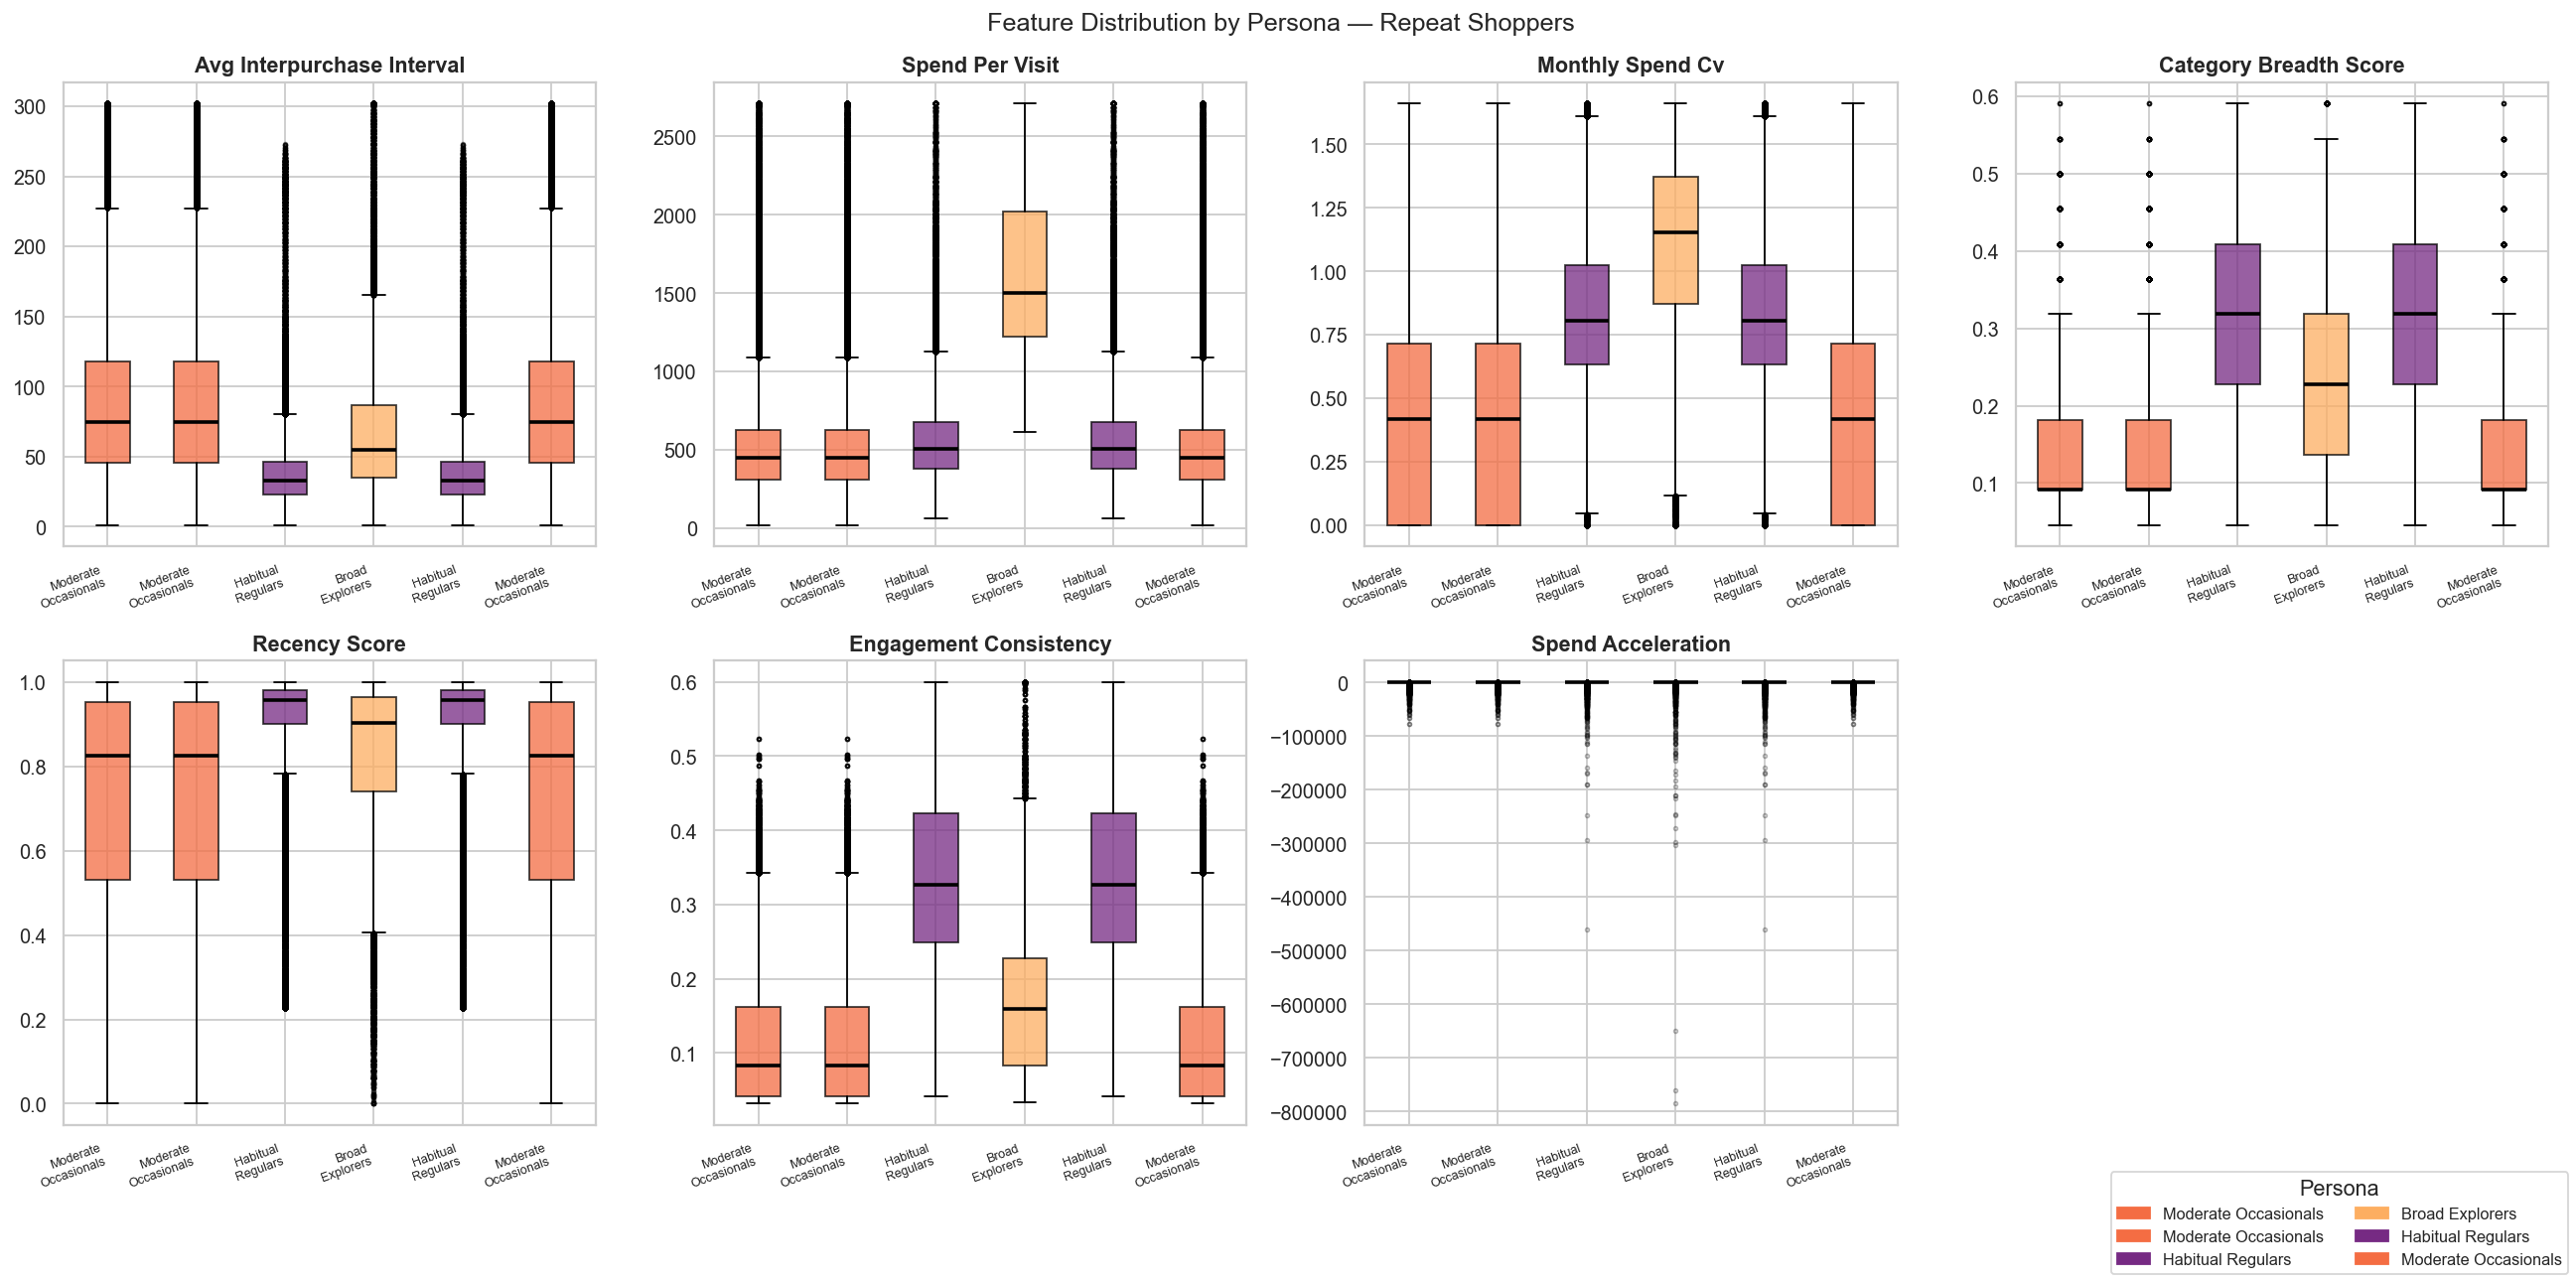

In [21]:
# ── 6.1 Boxplots — feature distribution per persona ──────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Feature Distribution by Persona — Repeat Shoppers', fontsize=14)
axes = axes.flatten()

persona_list = [PERSONA_NAMES[c] for c in sorted(PERSONA_NAMES)]
colors_map   = {p: PALETTE[i % len(PALETTE)] for i, p in enumerate(persona_list)}

for ax, feat in zip(axes, ENG_FEATURES):
    data_list = [
        repeat[repeat['persona'] == p][feat].dropna()
              .clip(upper=repeat[feat].quantile(0.99))
        for p in persona_list
    ]
    bp = ax.boxplot(data_list, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(linewidth=1),
                    boxprops=dict(linewidth=1),
                    flierprops=dict(marker='o', markersize=2, alpha=0.3))
    for patch, p in zip(bp['boxes'], persona_list):
        patch.set_facecolor(colors_map[p])
        patch.set_alpha(0.75)

    ax.set_title(feat.replace('_',' ').title())
    ax.set_xticklabels([p.replace(' ','\n') for p in persona_list],
                       fontsize=7, rotation=20, ha='right')
    ax.set_ylabel('')

# Hide last empty subplot if odd number of features
if len(ENG_FEATURES) < len(axes):
    axes[-1].set_visible(False)

# Legend
patches = [mpatches.Patch(color=colors_map[p], label=p) for p in persona_list]
fig.legend(handles=patches, loc='lower right', ncol=2, fontsize=9, title='Persona')
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('RS_02_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


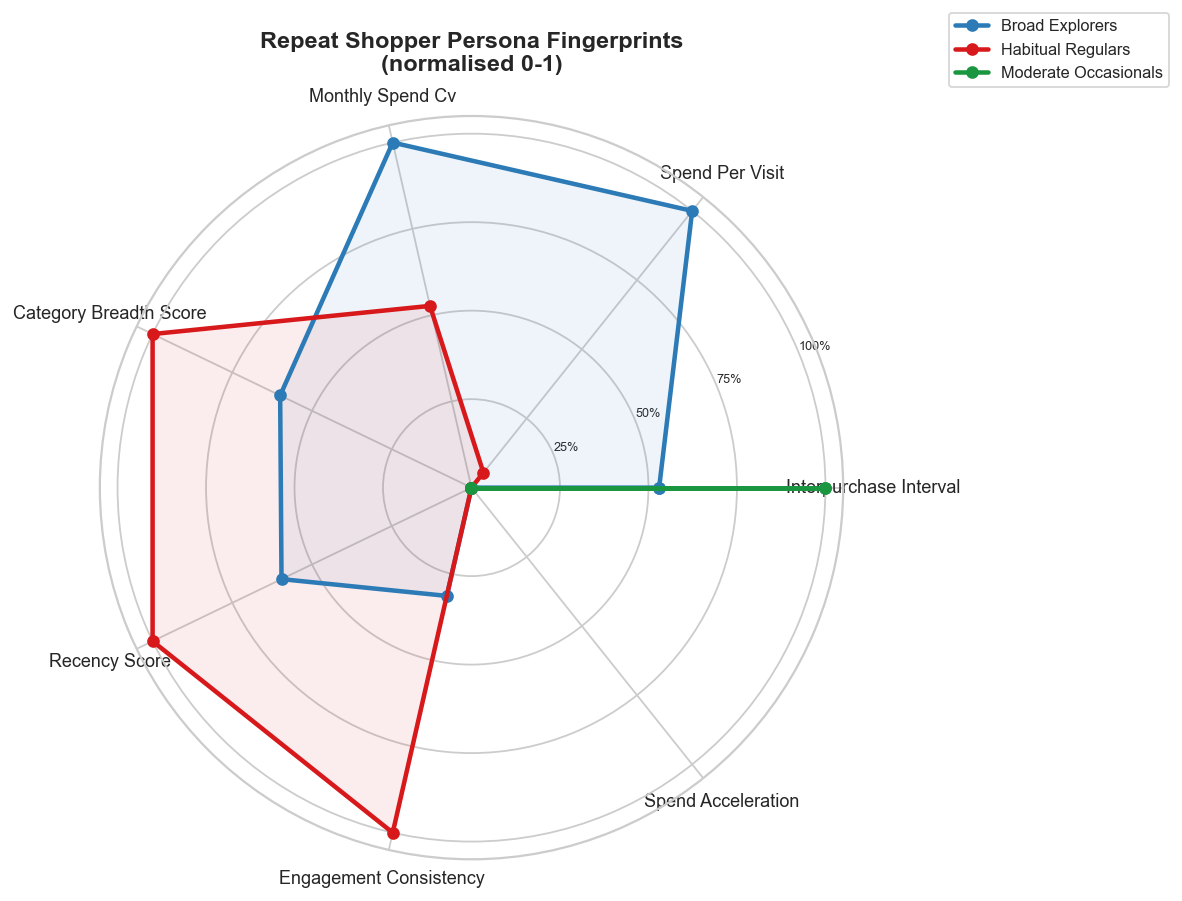

In [22]:
# ── 6.2 Radar chart — persona behavioral fingerprints ────────────────────────
radar_feats  = ENG_FEATURES
radar_labels = [f.replace('_',' ').replace('avg ','').title() for f in radar_feats]

# Normalise centroids 0-1 for radar
seg_radar = repeat.dropna(subset=['persona']).groupby('persona')[radar_feats].median()
seg_norm  = (seg_radar - seg_radar.min()) / (seg_radar.max() - seg_radar.min() + 1e-9)

N      = len(radar_feats)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for i, (persona, row) in enumerate(seg_norm.iterrows()):
    vals = row.tolist() + [row.tolist()[0]]
    color = PALETTE[i % len(PALETTE)]
    ax.plot(angles, vals, 'o-', linewidth=2.5, color=color, label=persona)
    ax.fill(angles, vals, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=10)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%','50%','75%','100%'], fontsize=7)
ax.set_title('Repeat Shopper Persona Fingerprints\n(normalised 0-1)',
             fontsize=13, fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.45, 1.15), fontsize=9)
plt.tight_layout()
plt.savefig('RS_03_radar.png', dpi=150, bbox_inches='tight')
plt.show()


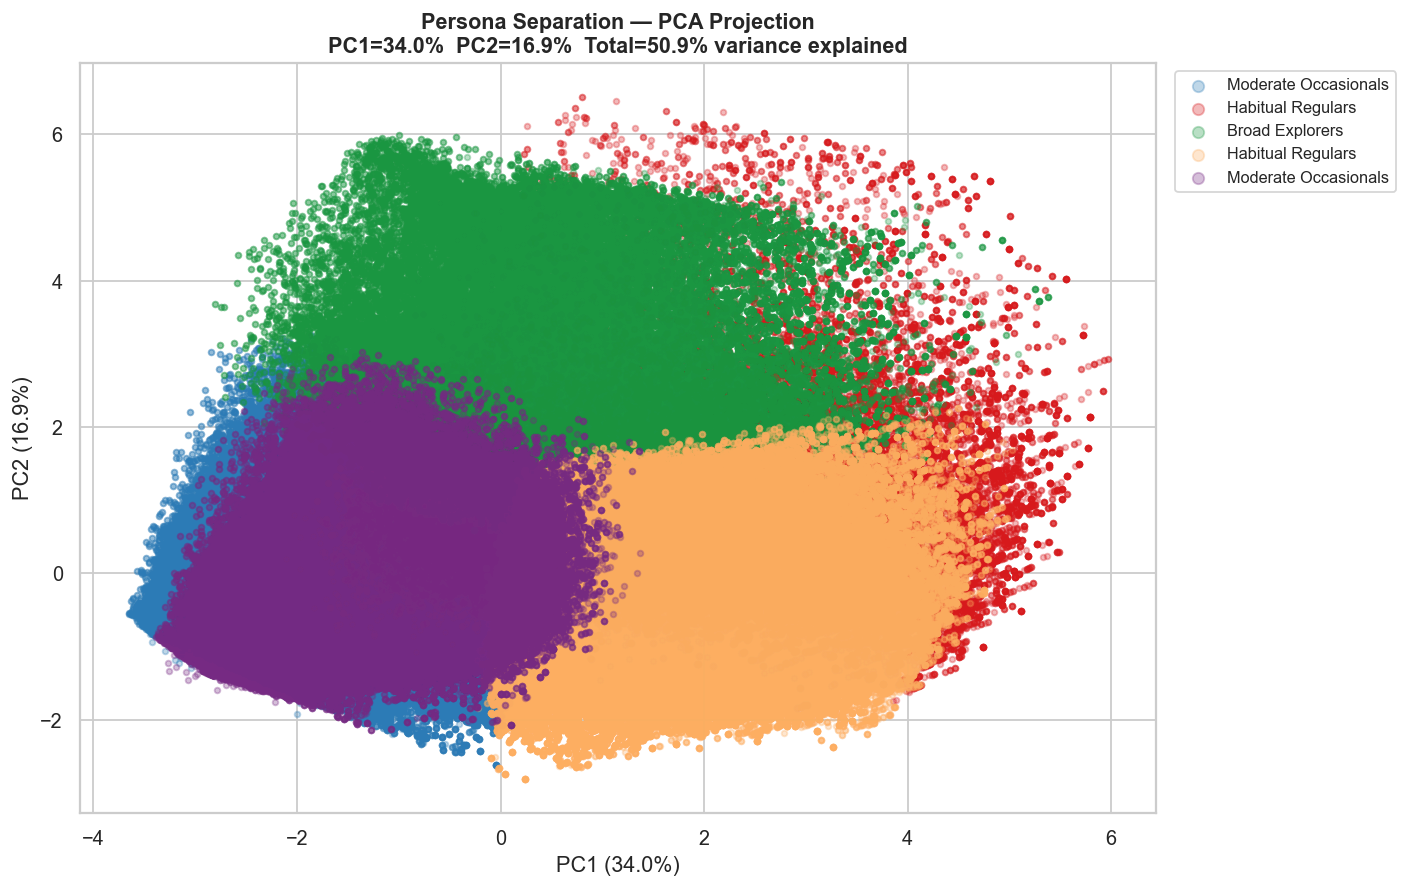

In [23]:
# ── 6.3 PCA scatter — cluster separation ─────────────────────────────────────
pca   = PCA(n_components=2, random_state=RANDOM_STATE)
Xp    = pca.fit_transform(X_scaled)
ve    = pca.explained_variance_ratio_

pca_df = cluster_input[['customer_id','cluster']].copy()
pca_df['pc1'] = Xp[:, 0]
pca_df['pc2'] = Xp[:, 1]

fig, ax = plt.subplots(figsize=(11, 7))
for c in sorted(pca_df['cluster'].unique()):
    mask  = pca_df['cluster'] == c
    label = PERSONA_NAMES.get(int(c), f'Cluster {c}')
    ax.scatter(pca_df.loc[mask,'pc1'], pca_df.loc[mask,'pc2'],
               label=label, alpha=0.3, s=10, color=PALETTE[int(c) % len(PALETTE)])

ax.set_title(f'Persona Separation — PCA Projection\n'
             f'PC1={ve[0]*100:.1f}%  PC2={ve[1]*100:.1f}%  '
             f'Total={sum(ve)*100:.1f}% variance explained',
             fontweight='bold')
ax.set_xlabel(f'PC1 ({ve[0]*100:.1f}%)'); ax.set_ylabel(f'PC2 ({ve[1]*100:.1f}%)')
ax.legend(fontsize=9, markerscale=2, bbox_to_anchor=(1.01,1))
plt.tight_layout()
plt.savefig('RS_04_pca.png', dpi=150, bbox_inches='tight')
plt.show()


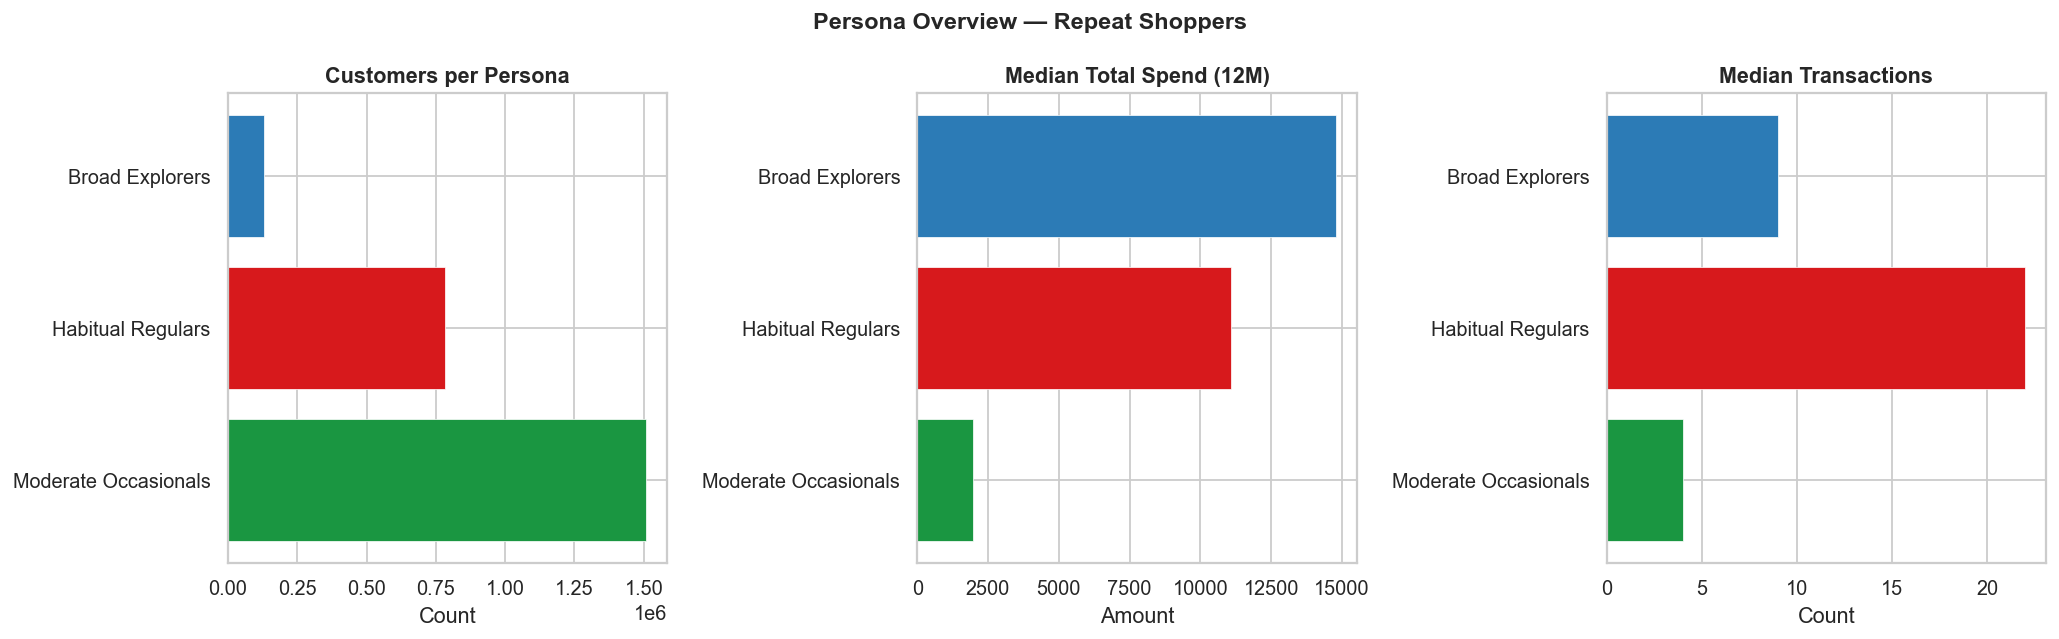

In [24]:
# ── 6.4 Persona size + median spend overview ──────────────────────────────────
persona_stats = (
    repeat.dropna(subset=['persona'])
          .groupby('persona')
          .agg(
              n_customers  = ('customer_id',       'count'),
              median_spend = ('total_spend_12m',   'median'),
              median_txns  = ('total_transactions_12m', 'median'),
          )
          .sort_values('median_spend', ascending=False)
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Persona Overview — Repeat Shoppers', fontweight='bold')

colors = [PALETTE[i % len(PALETTE)] for i in range(len(persona_stats))]

for ax, col, title, ylabel in [
    (axes[0], 'n_customers',  'Customers per Persona',   'Count'),
    (axes[1], 'median_spend', 'Median Total Spend (12M)', 'Amount'),
    (axes[2], 'median_txns',  'Median Transactions',      'Count'),
]:
    ax.barh(persona_stats.index, persona_stats[col],
            color=colors, edgecolor='white', linewidth=0.4)
    ax.set_title(title); ax.set_xlabel(ylabel)
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('RS_05_persona_overview.png', dpi=150, bbox_inches='tight')
plt.show()


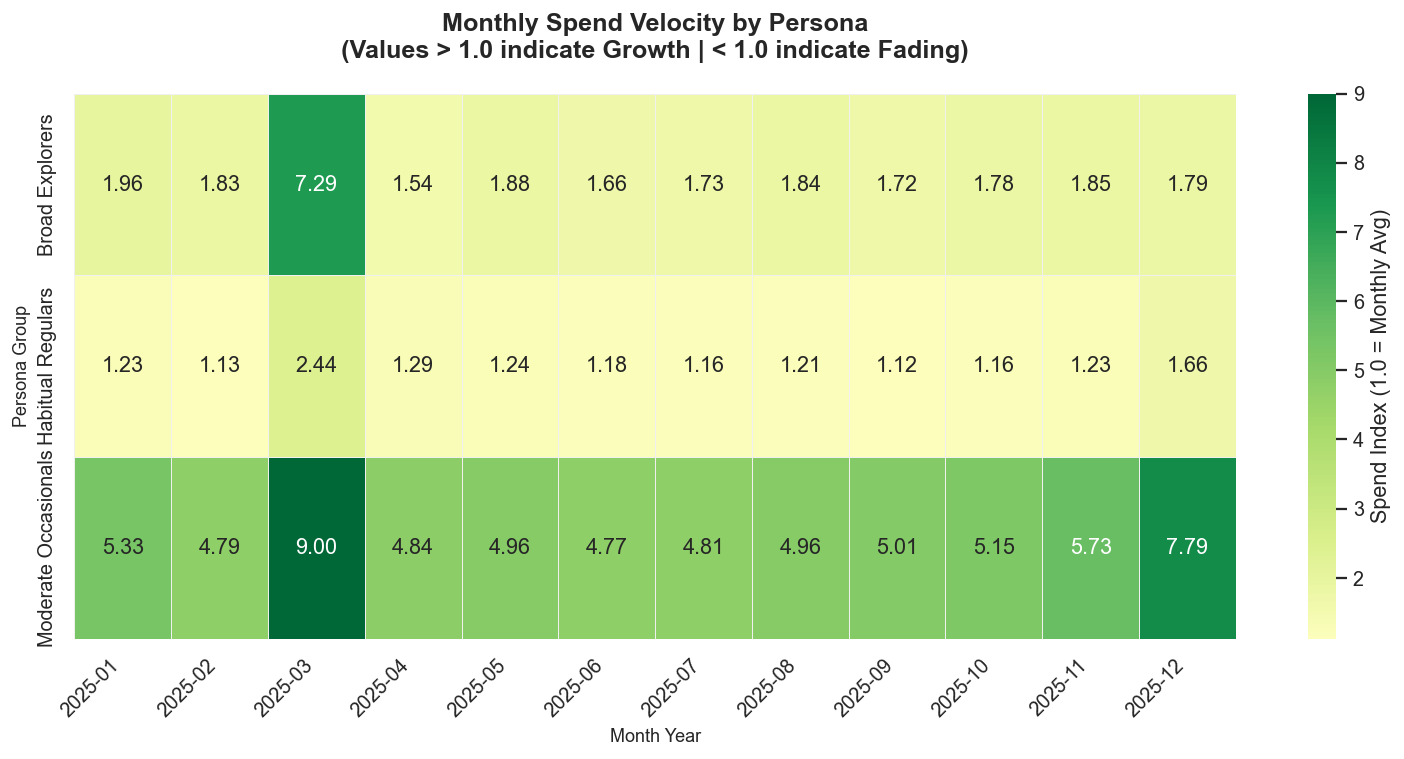

In [25]:
# ── 6.5 Spend acceleration heatmap — optimized ──────────────────────────────

# 1. Create mapping Series for Persona and Spend (Avoids the 21GB merge)
# We drop duplicates to ensure the index is unique, preventing InvalidIndexError
persona_map = repeat[['customer_id', 'persona']].drop_duplicates('customer_id').set_index('customer_id')['persona']
spend_map = repeat[['customer_id', 'avg_monthly_spend']].drop_duplicates('customer_id').set_index('customer_id')['avg_monthly_spend']

# 2. Map Persona and Spend directly to the panel (Very memory efficient)
repeat_panel['persona'] = repeat_panel['customer_id'].map(persona_map)
repeat_panel['avg_monthly_spend'] = repeat_panel['customer_id'].map(spend_map)

# 3. Calculate Spend Index on-the-fly to save space
# We only calculate this for active months to save CPU/Memory
active_mask = (repeat_panel['is_active'] == 1) & (repeat_panel['persona'].notna())

# Use a temporary series for calculation to avoid adding another massive column permanently
spend_index = (
    repeat_panel.loc[active_mask, 'total_spend'] / 
    repeat_panel.loc[active_mask, 'avg_monthly_spend'].clip(lower=0.01)
)

# 4. Pivot directly from the filtered data
pivot = (
    repeat_panel[active_mask].assign(spend_index=spend_index)
    .groupby(['persona', 'year_month'])['spend_index']
    .median()
    .unstack('year_month')
)

# Convert columns to string for plotting
pivot.columns = [str(c) for c in pivot.columns]

# 5. Visualization
fig, ax = plt.subplots(figsize=(max(12, len(pivot.columns) * 0.8), 6))
sns.heatmap(pivot, 
            annot=True, # Adding numbers can help identify "Fading" groups specifically
            fmt=".2f",
            cmap='RdYlGn', 
            center=1.0,
            linewidths=0.5, 
            linecolor='#f0f0f0', 
            ax=ax,
            cbar_kws={'label': 'Spend Index (1.0 = Monthly Avg)'})

ax.set_title('Monthly Spend Velocity by Persona\n(Values > 1.0 indicate Growth | < 1.0 indicate Fading)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Month Year', fontsize=10)
ax.set_ylabel('Persona Group', fontsize=10)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('RS_06_spend_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

# Cleanup: If memory is still tight, remove the temporary persona column from panel
# repeat_panel.drop(columns=['persona', 'avg_monthly_spend'], inplace=True)

---
## 7. Strategic Business Recommendations

Five actionable recommendations derived from the persona patterns.
Each maps to a specific persona and a measurable business outcome.


In [26]:
# ── 7.1 Recommendation framework ─────────────────────────────────────────────
# Printed as a structured summary. Adapt trigger logic to your CRM system.

recommendations = [
    {
        "number"  : 1,
        "title"   : "Churn Prevention — Fading High-Loyalty",
        "persona" : "Fading High-Loyalty",
        "signal"  : "spend_acceleration < 0 AND recency_score < 0.4",
        "action"  : "Trigger personalised win-back campaign 30 days before expected lapse. "
                    "Offer a loyalty reward tied to their historically top category. "
                    "Message: 'We noticed you haven't visited recently — here's something for your baby.'",
        "metric"  : "Reactivation rate within 60 days of campaign send",
    },
    {
        "number"  : 2,
        "title"   : "Basket Upsell — Infrequent High-Spenders",
        "persona" : "Infrequent High-Spenders",
        "signal"  : "spend_per_visit in top quartile AND avg_interpurchase_interval > median",
        "action"  : "These shoppers spend a lot per trip but come infrequently. "
                    "Target them with 'Complete Your Stock' bundles 2 weeks before their predicted "
                    "next visit window (estimated from avg_gap_days). "
                    "Cross-sell into adjacent category they haven't tried (low category_breadth_score).",
        "metric"  : "Avg basket size uplift per visit; second-category penetration rate",
    },
    {
        "number"  : 3,
        "title"   : "Loyalty Programme Recruitment — Habitual Regulars",
        "persona" : "Habitual Regulars",
        "signal"  : "engagement_consistency in top quartile AND avg_interpurchase_interval < median",
        "action"  : "These are your most reliable shoppers. Recruit them into a tiered loyalty programme "
                    "or baby subscription box. Their regularity makes subscription economics predictable. "
                    "Reward consistency explicitly: 'Shop 4 months in a row, get a free gift.'",
        "metric"  : "Loyalty programme enrolment rate; 12-month retention rate",
    },
    {
        "number"  : 4,
        "title"   : "Category Expansion — Broad Explorers",
        "persona" : "Broad Explorers",
        "signal"  : "category_breadth_score in top quartile",
        "action"  : "Explorers are already open to trying new categories. "
                    "Use their avg_new_subdept_per_month signal to time cross-sell emails "
                    "right after they've just entered a new category (peak curiosity window). "
                    "Recommend the next logical category in the baby development arc "
                    "(e.g., entered Food & Supplements → recommend Training & Potty).",
        "metric"  : "Category penetration rate; avg_new_subdept_per_month uplift",
    },
    {
        "number"  : 5,
        "title"   : "Spend Stabilisation — Volatile Shoppers",
        "persona" : "Volatile Shoppers",
        "signal"  : "monthly_spend_cv in top quartile",
        "action"  : "High spend volatility often reflects reactive (promo-driven) purchasing. "
                    "Offer a predictable subscription or auto-replenishment for their top category "
                    "to reduce decision friction and smooth spend. "
                    "Test a 'Subscribe & Save' mechanic — even a 5% discount drives "
                    "regularisation and improves forecasting accuracy.",
        "metric"  : "Monthly spend CV reduction; subscription attach rate",
    },
]

for rec in recommendations:
    print(f"{'='*65}")
    print(f"  REC {rec['number']}: {rec['title'].upper()}")
    print(f"{'='*65}")
    print(f"  Target persona : {rec['persona']}")
    print(f"  Trigger signal : {rec['signal']}")
    print(f"  Action         : {rec['action']}")
    print(f"  Success metric : {rec['metric']}")
    print()


  REC 1: CHURN PREVENTION — FADING HIGH-LOYALTY
  Target persona : Fading High-Loyalty
  Trigger signal : spend_acceleration < 0 AND recency_score < 0.4
  Action         : Trigger personalised win-back campaign 30 days before expected lapse. Offer a loyalty reward tied to their historically top category. Message: 'We noticed you haven't visited recently — here's something for your baby.'
  Success metric : Reactivation rate within 60 days of campaign send

  REC 2: BASKET UPSELL — INFREQUENT HIGH-SPENDERS
  Target persona : Infrequent High-Spenders
  Trigger signal : spend_per_visit in top quartile AND avg_interpurchase_interval > median
  Action         : These shoppers spend a lot per trip but come infrequently. Target them with 'Complete Your Stock' bundles 2 weeks before their predicted next visit window (estimated from avg_gap_days). Cross-sell into adjacent category they haven't tried (low category_breadth_score).
  Success metric : Avg basket size uplift per visit; second-catego

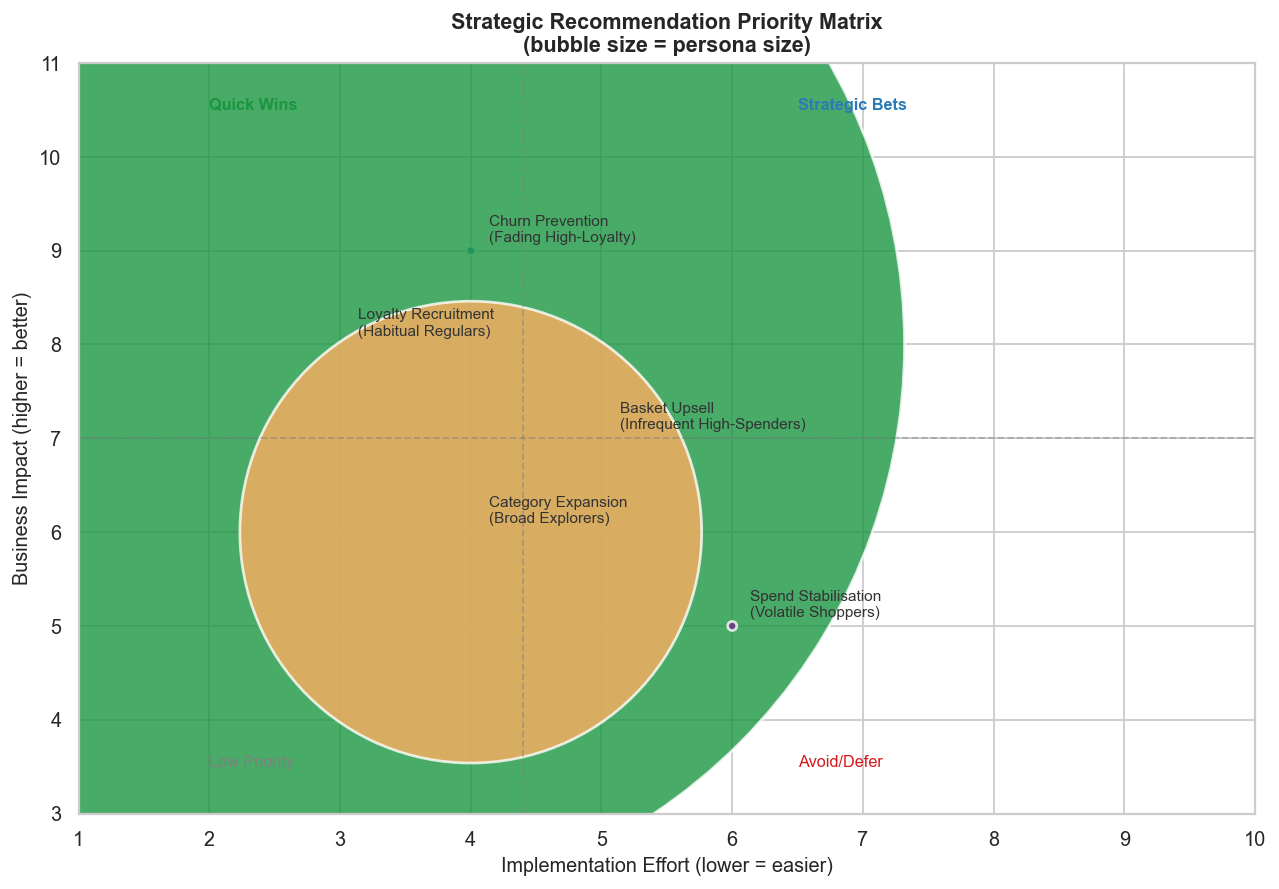

In [27]:
# ── 7.2 Priority matrix — impact vs effort ────────────────────────────────────
# Qualitative scoring: impact = revenue potential, effort = implementation complexity

rec_data = {
    'Recommendation'   : ['Churn Prevention\n(Fading High-Loyalty)',
                          'Basket Upsell\n(Infrequent High-Spenders)',
                          'Loyalty Recruitment\n(Habitual Regulars)',
                          'Category Expansion\n(Broad Explorers)',
                          'Spend Stabilisation\n(Volatile Shoppers)'],
    'Business Impact'  : [9, 7, 8, 6, 5],   # 1-10
    'Implementation'   : [4, 5, 3, 4, 6],    # effort (lower = easier)
    'Persona Size'     : [
        repeat[repeat['persona']=='Fading High-Loyalty'].shape[0]         if 'Fading High-Loyalty'        in repeat['persona'].values else 50,
        repeat[repeat['persona']=='Infrequent High-Spenders'].shape[0]    if 'Infrequent High-Spenders'   in repeat['persona'].values else 50,
        repeat[repeat['persona']=='Habitual Regulars'].shape[0]           if 'Habitual Regulars'           in repeat['persona'].values else 50,
        repeat[repeat['persona']=='Broad Explorers'].shape[0]             if 'Broad Explorers'             in repeat['persona'].values else 50,
        repeat[repeat['persona']=='Volatile Shoppers'].shape[0]           if 'Volatile Shoppers'           in repeat['persona'].values else 50,
    ],
}
rec_df = pd.DataFrame(rec_data)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    rec_df['Implementation'], rec_df['Business Impact'],
    s=[n * 0.5 for n in rec_df['Persona Size']],
    c=PALETTE[:len(rec_df)], alpha=0.8, edgecolors='white', linewidth=1.5
)

for _, row in rec_df.iterrows():
    ax.annotate(row['Recommendation'],
                xy=(row['Implementation'], row['Business Impact']),
                xytext=(10, 5), textcoords='offset points',
                fontsize=8.5, color='#333333')

ax.axvline(rec_df['Implementation'].mean(), color='grey', linestyle='--', alpha=0.5, lw=1)
ax.axhline(rec_df['Business Impact'].mean(), color='grey', linestyle='--', alpha=0.5, lw=1)

ax.set_xlabel('Implementation Effort (lower = easier)', fontsize=11)
ax.set_ylabel('Business Impact (higher = better)', fontsize=11)
ax.set_title('Strategic Recommendation Priority Matrix\n(bubble size = persona size)',
             fontweight='bold')
ax.set_xlim(1, 10); ax.set_ylim(3, 11)

# Quadrant labels
ax.text(2, 10.5, 'Quick Wins', color='#1A9641', fontsize=9, fontweight='bold')
ax.text(6.5, 10.5, 'Strategic Bets', color='#2C7BB6', fontsize=9, fontweight='bold')
ax.text(2, 3.5,  'Low Priority', color='grey', fontsize=9)
ax.text(6.5, 3.5,'Avoid/Defer', color='#D7191C', fontsize=9)

plt.tight_layout()
plt.savefig('RS_07_priority_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 8. Output

In [28]:
# ── 8.1 Save repeat shopper profile with personas ─────────────────────────────
out_cols = [
    'customer_id',
    # Engineered features
    'avg_interpurchase_interval', 'spend_per_visit', 'monthly_spend_cv',
    'category_breadth_score', 'recency_score', 'engagement_consistency',
    'spend_acceleration',
    # Phase 1 features
    'total_transactions_12m', 'total_spend_12m', 'active_months',
    'activity_span_days', 'engagement_density', 'avg_gap_days',
    'purchase_regularity_cv', 'days_since_last_purchase',
    'total_spend_12m', 'avg_spend_per_visit', 'spend_volatility_avg',
    'journey_stage', 'top_subdept', 'distinct_subdept_count',
    # Cluster output
    'cluster', 'persona',
]
out_cols = list(dict.fromkeys([c for c in out_cols if c in repeat.columns]))

repeat[out_cols].to_parquet('repeat_shopper_personas.parquet', index=False)
repeat[out_cols].to_csv('repeat_shopper_personas.csv', index=False)
print(f"Saved: repeat_shopper_personas.parquet")
print(f"  {len(repeat):,} repeat shoppers × {len(out_cols)} columns")


Saved: repeat_shopper_personas.parquet
  2,422,295 repeat shoppers × 23 columns


In [29]:
# ── 8.2 Persona summary card ─────────────────────────────────────────────────
persona_card = (
    repeat.dropna(subset=['persona'])
          .groupby('persona')
          .agg(
              n_customers              = ('customer_id',                  'count'),
              median_spend_12m         = ('total_spend_12m',              'median'),
              median_transactions      = ('total_transactions_12m',       'median'),
              median_gap_days          = ('avg_interpurchase_interval',   'median'),
              median_spend_per_visit   = ('spend_per_visit',              'median'),
              median_spend_cv          = ('monthly_spend_cv',             'median'),
              median_recency_score     = ('recency_score',                'median'),
              median_consistency       = ('engagement_consistency',       'median'),
              median_acceleration      = ('spend_acceleration',           'median'),
              median_breadth           = ('category_breadth_score',       'median'),
          )
          .sort_values('median_spend_12m', ascending=False)
)

persona_card['pct_of_repeat'] = (
    persona_card['n_customers'] / len(repeat) * 100
).round(1).astype(str) + '%'

# Top journey stage per persona
stage_ct = pd.crosstab(repeat['persona'], repeat['journey_stage'])
persona_card['top_stage'] = stage_ct.idxmax(axis=1)

persona_card.to_csv('repeat_persona_summary.csv')
print("Saved: repeat_persona_summary.csv\n")
print("=== Persona Summary Card ===")
persona_card.T


Saved: repeat_persona_summary.csv

=== Persona Summary Card ===


persona,Broad Explorers,Habitual Regulars,Moderate Occasionals
n_customers,130831,781845,1509619
median_spend_12m,14789.750,11085.750,1967.000
median_transactions,9.000,22.000,4.000
median_gap_days,55.000,33.000,74.500
median_spend_per_visit,1501.373,505.756,448.833
median_spend_cv,1.151,0.804,0.419
median_recency_score,0.904,0.958,0.825
median_consistency,0.160,0.326,0.083
median_acceleration,0.000,0.000,0.000
median_breadth,0.227,0.318,0.091


# time Analysis

Raw repeat-shopper rows : 7,166,839
Unique subdepartments   : 26
Date range              : 2025-01-01 → 2025-12-31

Journey month range: 1 – 12
journey_month
1     991443
2     585467
3     313689
4     190643
5     123525
6      82013
7      54189
8      35622
9      22530
10     13480
11      7024
12      2670

Aggregated rows: 297  |  Subdepts: 26


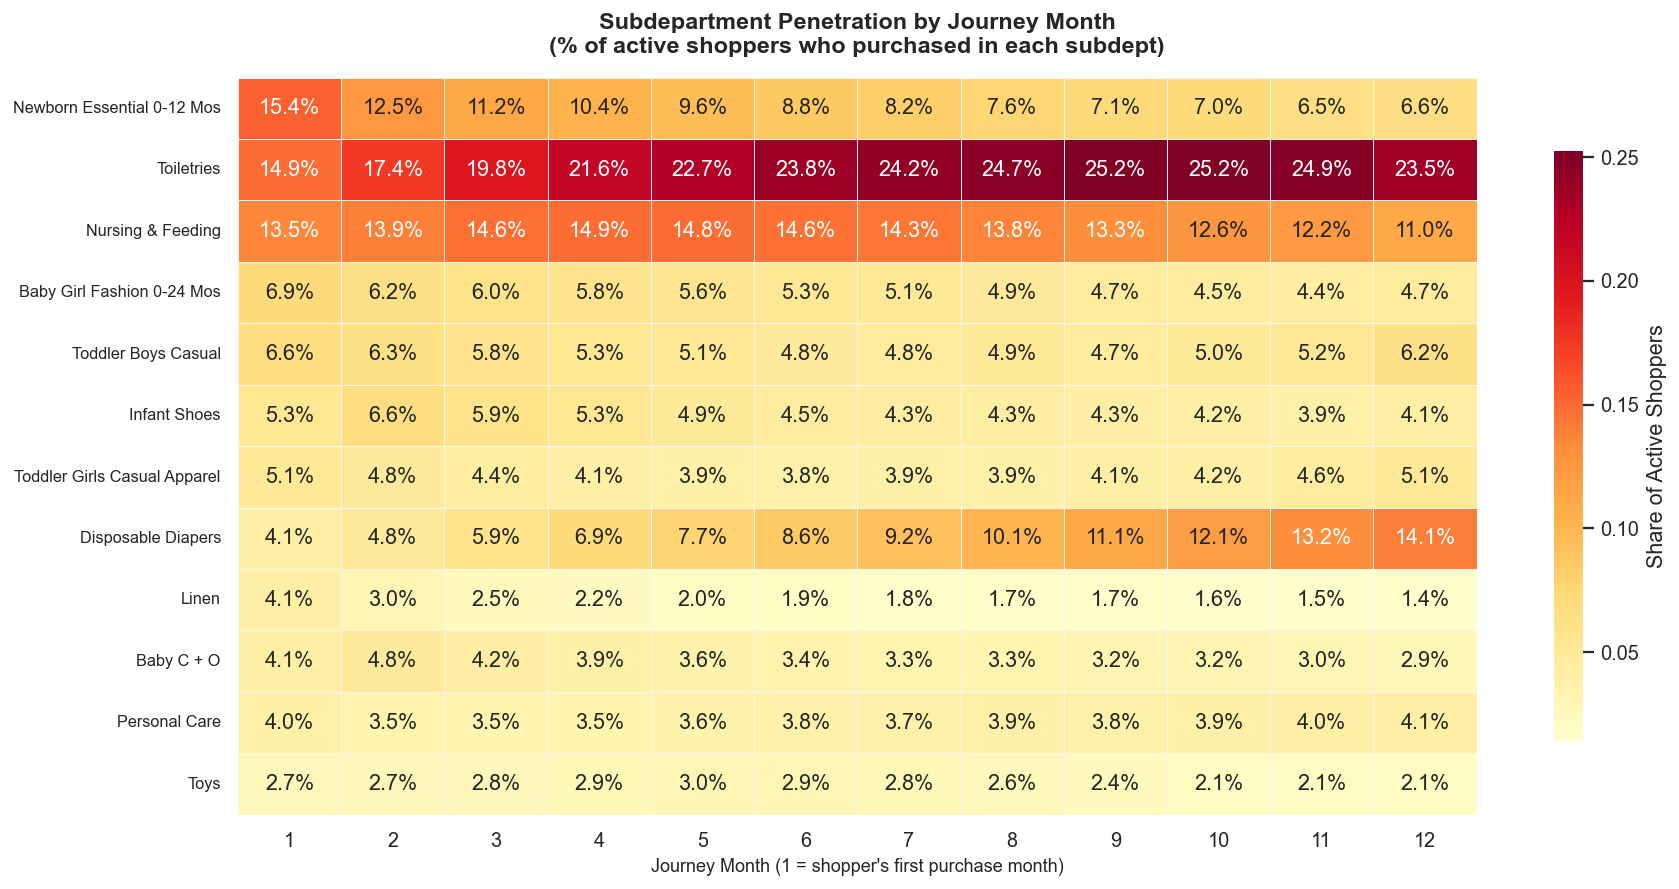

Saved: RS_10a_subdept_heatmap.png


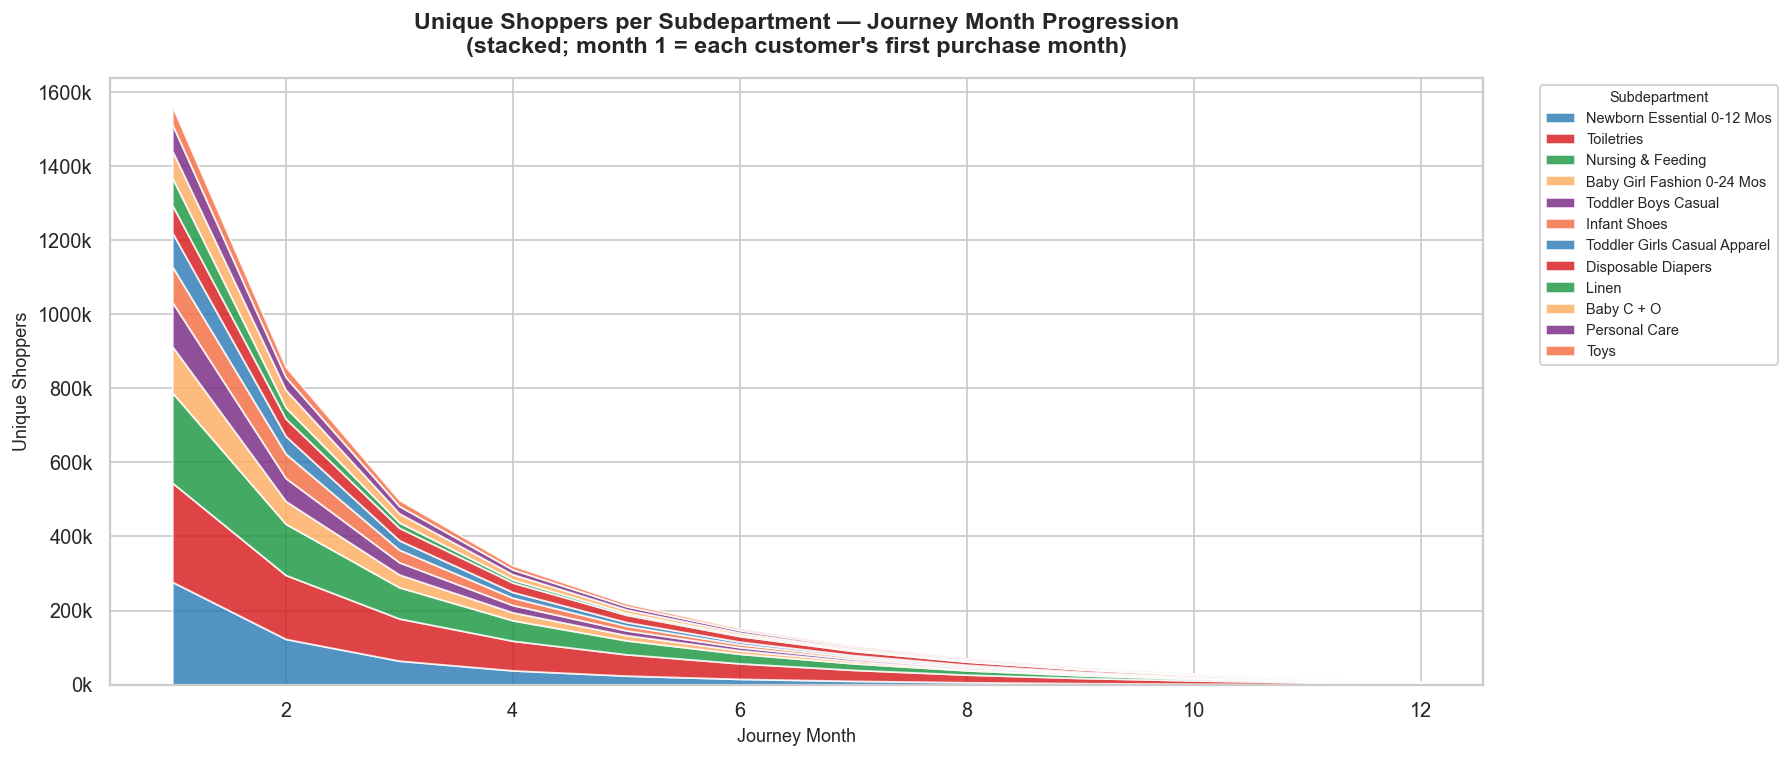

Saved: RS_10b_subdept_stacked_area.png


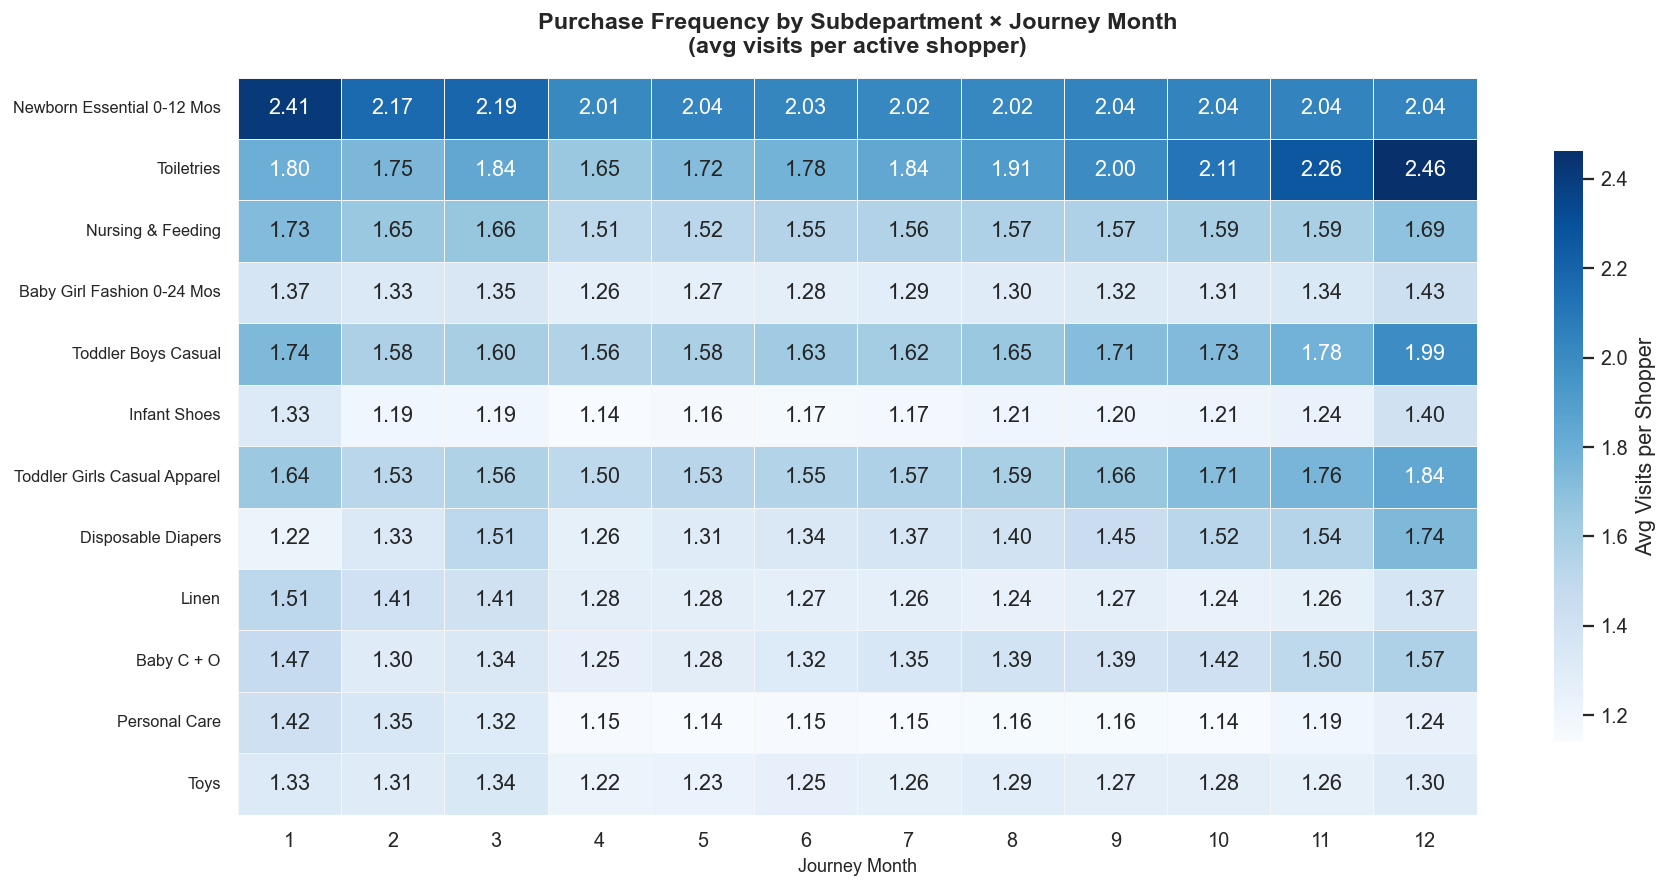

Saved: RS_10c_subdept_freq_heatmap.png


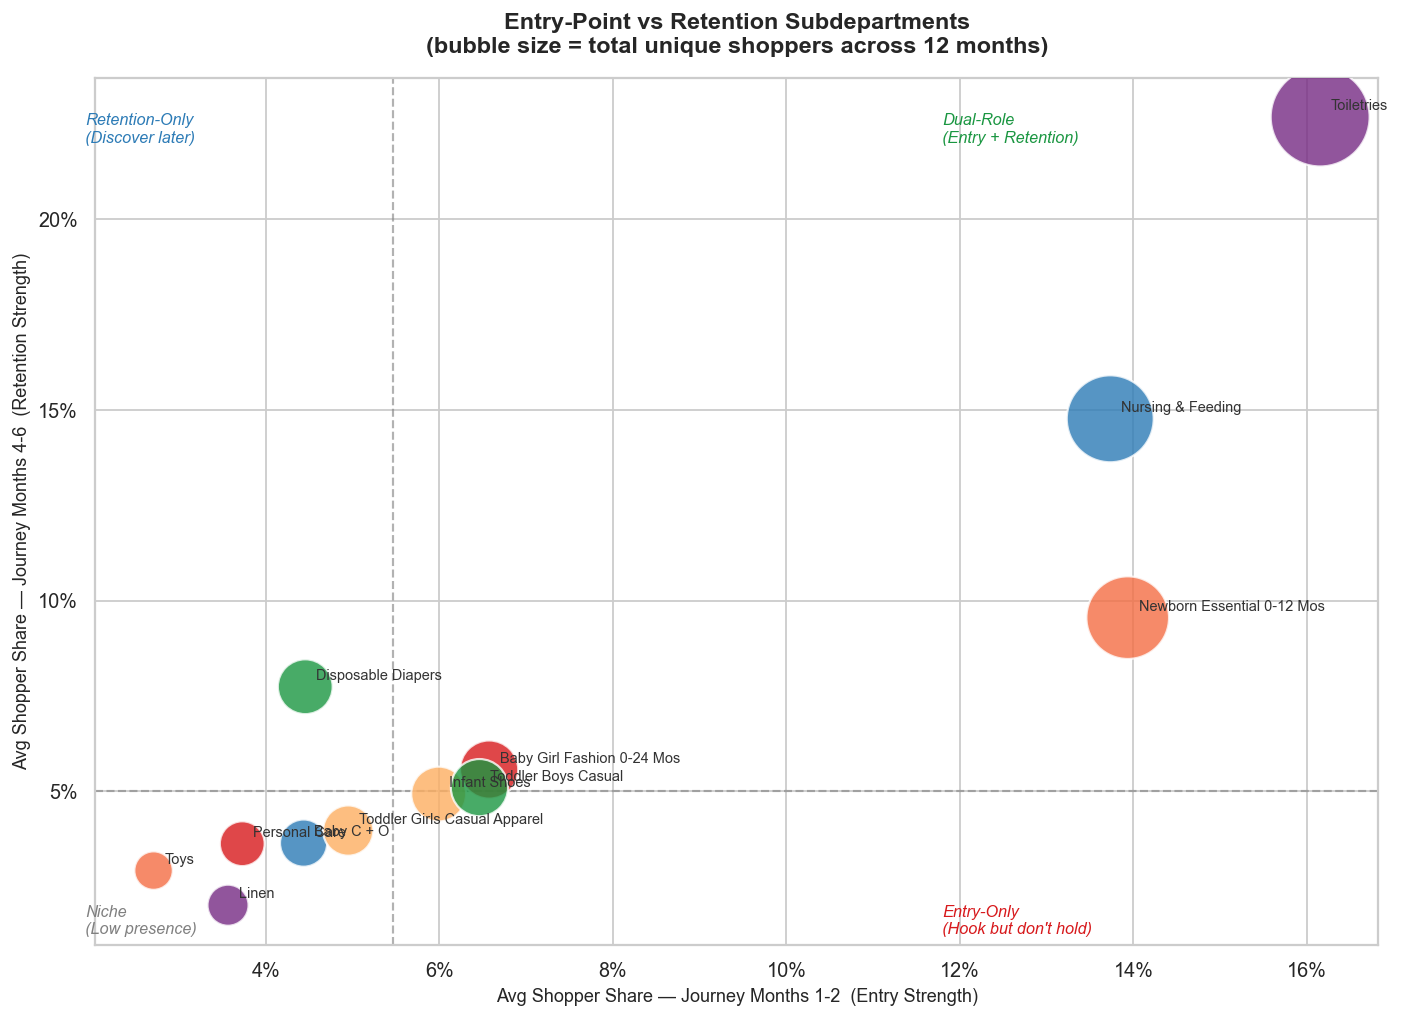

Saved: RS_10d_entry_vs_retention.png

  SUBDEPARTMENT ROLE CLASSIFICATION
  Entry threshold  : ≥ 5.5% shopper share in months 1-2
  Retention threshold: ≥ 5.0% shopper share in months 4-6

  [DUAL-ROLE]  (5 subdepts)
    Toiletries                               entry=16.2%  retention=22.7%  shoppers=813,723
    Nursing & Feeding                        entry=13.7%  retention=14.8%  shoppers=628,515
    Newborn Essential 0-12 Mos               entry=13.9%  retention=9.6%  shoppers=568,004
    Baby Girl Fashion 0-24 Mos               entry=6.6%  retention=5.6%  shoppers=281,322
    Toddler Boys Casual                      entry=6.5%  retention=5.1%  shoppers=271,871

  [ENTRY-ONLY]  (1 subdepts)
    Infant Shoes                             entry=6.0%  retention=4.9%  shoppers=249,826

  [RETENTION-ONLY]  (1 subdepts)
    Disposable Diapers                       entry=4.5%  retention=7.7%  shoppers=249,726

  [NICHE]  (5 subdepts)
    Toddler Girls Casual Apparel             entry=4.9%  re

In [31]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 10 — Time-Bound Subdepartment Behaviour
# Goal : Identify ENTRY-POINT subdepartments (dominant in a shopper's first
#         months) vs RETENTION subdepartments (dominant in months 4-6+).
# Inputs: repeat          — repeat shopper master profile (from Section 4)
#         raw             — raw transaction rows (combined_shoppers.parquet)
#                           filtered to repeat shoppers and promo-removed
# Method: All aggregations are vectorised — no apply/lambda.
# Outputs: 4 charts saved as PNG + printed entry/retention summary table
# ══════════════════════════════════════════════════════════════════════════════

# ── 10.0  Load raw transactions for repeat shoppers ───────────────────────────
#
#  We need subdepartment-level rows, which live in the raw data (not the
#  profile).  We re-use the same load + clean pattern from Section 2 of
#  baby_shopper_phase1_binge.ipynb so behaviour is identical.
#
#  If you already have the cleaned raw frame in memory under a different name,
#  replace the read_parquet call with that variable.

PROMO_SUBCLASS     = 'md promo'
PROMO_SUBDEPTS     = {'iw promotions', 'iaf clearance', 'iaf promotions'}

raw_all = pd.read_parquet(r"C:\Users\dacdatalabs.ojt2\Desktop\workspace\DS\datasets\combined_shoppers.parquet")

# Normalise text (consistent with Phase 1)
raw_all['subdepartment_cleaned'] = raw_all['subdepartment_cleaned'].str.lower().str.strip()
raw_all['subclass']              = raw_all['subclass'].str.lower().str.strip()

# Remove promo rows
promo_mask = (
    raw_all['subclass'].eq(PROMO_SUBCLASS) |
    raw_all['subdepartment_cleaned'].isin(PROMO_SUBDEPTS)
)
raw_all = raw_all[~promo_mask].copy()

# Parse dates (handle "Sept" → "Sep" quirk documented in schema notes)
raw_all['header_tran_date'] = raw_all['header_tran_date'].str.replace('Sept', 'Sep', regex=False)
raw_all['date']             = pd.to_datetime(raw_all['header_tran_date'], format='%d %b %Y')

# Encode customer_id to integer — must match Phase 1 factorize order.
# If customer_id already exists as int in your session, skip this block.
raw_all['customer_id'] = pd.factorize(raw_all['gcr_persistent_id'])[0]

# Filter down to repeat shoppers only (fast set-membership check)
repeat_ids = set(repeat['customer_id'].unique())
raw = raw_all[raw_all['customer_id'].isin(repeat_ids)].copy()
del raw_all   # free memory

print(f"Raw repeat-shopper rows : {len(raw):,}")
print(f"Unique subdepartments   : {raw['subdepartment_cleaned'].nunique()}")
print(f"Date range              : {raw['date'].min().date()} → {raw['date'].max().date()}")


# ── 10.1  Build customer-relative month-sequence index ────────────────────────
#
#  We want each shopper's JOURNEY MONTH (1 = month they first purchased,
#  2 = second calendar month they purchased, etc.) rather than the wall-clock
#  calendar month.  This aligns all shoppers to the same relative timeline so
#  we can compare "month 1 behaviour" across customers who joined at different
#  calendar dates.
#
#  Steps (vectorised):
#    a. Find each customer's first purchase month.
#    b. Assign every transaction its calendar year-month integer.
#    c. Rank the distinct year-months per customer → journey_month (1, 2, 3 …).
#    d. Join back to the raw rows.

# a. Calendar year-month integer  (e.g. 202401)
raw['ym'] = raw['date'].dt.year * 100 + raw['date'].dt.month

# b. Distinct customer × year-month combinations
cust_ym = raw[['customer_id', 'ym']].drop_duplicates().copy()

# c. Dense rank within customer — gives journey_month without apply/lambda
#    sort then use cumcount (0-based) → +1 for 1-based month numbering
cust_ym = cust_ym.sort_values(['customer_id', 'ym'])
cust_ym['journey_month'] = (
    cust_ym.groupby('customer_id').cumcount() + 1
)

# d. Join back to raw transactions
raw = raw.merge(cust_ym[['customer_id', 'ym', 'journey_month']],
                on=['customer_id', 'ym'], how='left')

print(f"\nJourney month range: 1 – {raw['journey_month'].max()}")
print(raw.groupby('journey_month')['customer_id'].nunique()
        .rename('unique_shoppers').head(12).to_string())


# ── 10.2  Aggregate: unique shoppers + purchase frequency per subdept × month ─
#
#  Metrics per (journey_month, subdepartment):
#    • unique_shoppers   — distinct customer_ids  (breadth / reach)
#    • total_visits      — distinct (customer_id × date) pairs  (frequency proxy)
#    • purchase_freq     — total_visits / unique_shoppers  (avg visits per shopper)
#    • total_spend       — sum of total_sales  (value weight)

# Unique visits = unique customer × date combinations (no TxnID in schema)
cust_date = (raw[['customer_id', 'date', 'journey_month', 'subdepartment_cleaned']]
             .drop_duplicates())

agg = (
    raw
    .groupby(['journey_month', 'subdepartment_cleaned'], sort=True)
    .agg(
        unique_shoppers = ('customer_id',  'nunique'),
        total_visits    = ('date',          'count'),    # proxy for frequency
        total_spend     = ('total_sales',   'sum'),
    )
    .reset_index()
)

# Purchase frequency = visits per unique shopper
agg['purchase_freq'] = agg['total_visits'] / agg['unique_shoppers'].clip(lower=1)

# Limit to journey months 1-12 (most shoppers observed here)
agg = agg[agg['journey_month'].between(1, 12)].copy()

print(f"\nAggregated rows: {len(agg):,}  |  Subdepts: {agg['subdepartment_cleaned'].nunique()}")


# ── 10.3  Compute normalised share of shoppers per subdept × journey month ────
#
#  For the heatmap we want each cell to show what FRACTION of that month's
#  active shoppers visited this subdepartment.  This controls for the fact
#  that month-1 typically has the most shoppers.

total_shoppers_per_month = (
    agg.groupby('journey_month')['unique_shoppers'].sum()
      .rename('month_total')
)
agg = agg.merge(total_shoppers_per_month, on='journey_month')
agg['shopper_share'] = agg['unique_shoppers'] / agg['month_total'].clip(lower=1)

# Keep top-N subdepts by overall volume to keep charts readable
TOP_N = 12
top_subdepts = (
    agg.groupby('subdepartment_cleaned')['unique_shoppers']
       .sum()
       .nlargest(TOP_N)
       .index
       .tolist()
)
agg_top = agg[agg['subdepartment_cleaned'].isin(top_subdepts)].copy()
agg_top['subdept_label'] = agg_top['subdepartment_cleaned'].str.title()


# ── 10.4  CHART 1: Heatmap — Shopper Share by Subdept × Journey Month ─────────
#
#  Each cell = % of that month's active shoppers who visited that subdept.
#  Entry-point subdepts will glow in month 1-2; retention subdepts stay warm
#  through months 4-12.

pivot_share = (
    agg_top
    .pivot(index='subdept_label', columns='journey_month', values='shopper_share')
    .fillna(0)
)
# Sort rows by month-1 share descending → entry-points float to top
pivot_share = pivot_share.sort_values(1, ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    pivot_share,
    annot=True,
    fmt='.1%',
    cmap='YlOrRd',
    linewidths=0.4,
    linecolor='#f5f5f5',
    cbar_kws={'label': 'Share of Active Shoppers', 'shrink': 0.8},
    ax=ax,
)
ax.set_title(
    'Subdepartment Penetration by Journey Month\n'
    '(% of active shoppers who purchased in each subdept)',
    fontsize=13, fontweight='bold', pad=14,
)
ax.set_xlabel('Journey Month (1 = shopper\'s first purchase month)', fontsize=10)
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig('RS_10a_subdept_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: RS_10a_subdept_heatmap.png")


# ── 10.5  CHART 2: Stacked Area — Unique Shoppers by Subdept Over Journey ──────
#
#  Shows the RAW VOLUME of shoppers in each subdept across their journey.
#  Wide-to-narrow funnel = early-exit subdepts.
#  Flat or rising bands = retention/growth subdepts.

pivot_shoppers = (
    agg_top
    .pivot(index='journey_month', columns='subdept_label', values='unique_shoppers')
    .fillna(0)
)
# Order columns by month-1 volume so legend matches visual order
col_order = pivot_shoppers.loc[1].sort_values(ascending=False).index.tolist()
pivot_shoppers = pivot_shoppers[col_order]

fig, ax = plt.subplots(figsize=(14, 6))
x = pivot_shoppers.index.tolist()
palette_ext = (PALETTE * ((TOP_N // len(PALETTE)) + 1))[:TOP_N]

ax.stackplot(
    x,
    [pivot_shoppers[col].values for col in col_order],
    labels=col_order,
    colors=palette_ext,
    alpha=0.82,
)
ax.set_title(
    'Unique Shoppers per Subdepartment — Journey Month Progression\n'
    '(stacked; month 1 = each customer\'s first purchase month)',
    fontsize=13, fontweight='bold', pad=14,
)
ax.set_xlabel('Journey Month', fontsize=10)
ax.set_ylabel('Unique Shoppers', fontsize=10)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e3:.0f}k'))
ax.legend(
    loc='upper right',
    bbox_to_anchor=(1.22, 1.0),
    fontsize=8,
    title='Subdepartment',
    title_fontsize=8,
    framealpha=0.9,
)
plt.tight_layout()
plt.savefig('RS_10b_subdept_stacked_area.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: RS_10b_subdept_stacked_area.png")


# ── 10.6  CHART 3: Purchase Frequency Heatmap ─────────────────────────────────
#
#  Shows avg visits-per-shopper per subdept × month.
#  High frequency in late months → habitual replenishment category.

pivot_freq = (
    agg_top
    .pivot(index='subdept_label', columns='journey_month', values='purchase_freq')
    .fillna(0)
)
pivot_freq = pivot_freq.reindex(pivot_share.index)   # same row order as chart 1

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    pivot_freq,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    linewidths=0.4,
    linecolor='#f5f5f5',
    cbar_kws={'label': 'Avg Visits per Shopper', 'shrink': 0.8},
    ax=ax,
)
ax.set_title(
    'Purchase Frequency by Subdepartment × Journey Month\n'
    '(avg visits per active shopper)',
    fontsize=13, fontweight='bold', pad=14,
)
ax.set_xlabel('Journey Month', fontsize=10)
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig('RS_10c_subdept_freq_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: RS_10c_subdept_freq_heatmap.png")


# ── 10.7  CHART 4: Entry-Point vs Retention Scatter ──────────────────────────
#
#  Each subdept plotted as a single point:
#    X = share in months 1-2  (entry-point strength)
#    Y = share in months 4-6  (retention strength)
#
#  Quadrant interpretation:
#    Top-right  → Dual-role: both entry AND retention
#    Top-left   → Retention-only: customers discover it after joining
#    Bottom-right→ Entry-only: hooks new shoppers but doesn't retain
#    Bottom-left → Niche: low presence throughout

ENTRY_MONTHS     = [1, 2]
RETENTION_MONTHS = [4, 5, 6]

entry_share = (
    agg_top[agg_top['journey_month'].isin(ENTRY_MONTHS)]
    .groupby('subdept_label')['shopper_share']
    .mean()
    .rename('entry_share')
)
retention_share = (
    agg_top[agg_top['journey_month'].isin(RETENTION_MONTHS)]
    .groupby('subdept_label')['shopper_share']
    .mean()
    .rename('retention_share')
)
vol = (
    agg_top.groupby('subdept_label')['unique_shoppers']
    .sum()
    .rename('total_shoppers')
)
scatter_df = pd.concat([entry_share, retention_share, vol], axis=1).dropna()

# Quadrant midpoints
q_x = scatter_df['entry_share'].median()
q_y = scatter_df['retention_share'].median()

fig, ax = plt.subplots(figsize=(11, 8))
sc = ax.scatter(
    scatter_df['entry_share'],
    scatter_df['retention_share'],
    s=(scatter_df['total_shoppers'] / scatter_df['total_shoppers'].max() * 3000).clip(lower=80),
    c=palette_ext[:len(scatter_df)],
    alpha=0.80,
    edgecolors='white',
    linewidth=1.2,
    zorder=3,
)
# Labels
for subdept, row in scatter_df.iterrows():
    ax.annotate(
        subdept,
        xy=(row['entry_share'], row['retention_share']),
        xytext=(6, 4),
        textcoords='offset points',
        fontsize=8,
        color='#333333',
    )
# Quadrant lines
ax.axvline(q_x, color='grey', linestyle='--', lw=1.2, alpha=0.6)
ax.axhline(q_y, color='grey', linestyle='--', lw=1.2, alpha=0.6)
# Quadrant labels
ax.text(q_x * 0.35, scatter_df['retention_share'].max() * 0.97,
        'Retention-Only\n(Discover later)',  color='#2C7BB6', fontsize=9, fontstyle='italic')
ax.text(scatter_df['entry_share'].max() * 0.73, scatter_df['retention_share'].max() * 0.97,
        'Dual-Role\n(Entry + Retention)', color='#1A9641', fontsize=9, fontstyle='italic')
ax.text(q_x * 0.35, q_y * 0.25,
        'Niche\n(Low presence)',             color='grey',    fontsize=9, fontstyle='italic')
ax.text(scatter_df['entry_share'].max() * 0.73, q_y * 0.25,
        'Entry-Only\n(Hook but don\'t hold)', color='#D7191C', fontsize=9, fontstyle='italic')

ax.set_title(
    'Entry-Point vs Retention Subdepartments\n'
    '(bubble size = total unique shoppers across 12 months)',
    fontsize=13, fontweight='bold', pad=14,
)
ax.set_xlabel('Avg Shopper Share — Journey Months 1-2  (Entry Strength)', fontsize=10)
ax.set_ylabel('Avg Shopper Share — Journey Months 4-6  (Retention Strength)', fontsize=10)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
plt.tight_layout()
plt.savefig('RS_10d_entry_vs_retention.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: RS_10d_entry_vs_retention.png")


# ── 10.8  Printed insight summary — Entry vs Retention classification ──────────

ENTRY_THRESHOLD     = q_x   # above = strong entry-point
RETENTION_THRESHOLD = q_y   # above = strong retention

def classify_subdept(row):
    e = row['entry_share'] >= ENTRY_THRESHOLD
    r = row['retention_share'] >= RETENTION_THRESHOLD
    if e and r:
        return 'Dual-Role'
    elif e and not r:
        return 'Entry-Only'
    elif not e and r:
        return 'Retention-Only'
    else:
        return 'Niche'

scatter_df['role'] = scatter_df.apply(classify_subdept, axis=1)

print("\n" + "=" * 70)
print("  SUBDEPARTMENT ROLE CLASSIFICATION")
print("  Entry threshold  : ≥ {:.1%} shopper share in months 1-2".format(ENTRY_THRESHOLD))
print("  Retention threshold: ≥ {:.1%} shopper share in months 4-6".format(RETENTION_THRESHOLD))
print("=" * 70)

for role in ['Dual-Role', 'Entry-Only', 'Retention-Only', 'Niche']:
    subset = scatter_df[scatter_df['role'] == role].sort_values(
        'total_shoppers', ascending=False
    )
    print(f"\n  [{role.upper()}]  ({len(subset)} subdepts)")
    for subdept, row in subset.iterrows():
        print(
            f"    {subdept:<40s} "
            f"entry={row['entry_share']:.1%}  "
            f"retention={row['retention_share']:.1%}  "
            f"shoppers={row['total_shoppers']:,.0f}"
        )

print("\n" + "=" * 70)
print("  KEY TAKEAWAYS")
print("=" * 70)

dual      = scatter_df[scatter_df['role'] == 'Dual-Role'].index.tolist()
entry_only= scatter_df[scatter_df['role'] == 'Entry-Only'].index.tolist()
ret_only  = scatter_df[scatter_df['role'] == 'Retention-Only'].index.tolist()

if dual:
    print(f"  • DUAL-ROLE (protect & amplify): {', '.join(dual)}")
    print( "    These are your core lifecycle anchors — dominant at acquisition")
    print( "    AND sustained long-term. Disruptions here will hurt both conversion")
    print( "    and retention.")
if entry_only:
    print(f"\n  • ENTRY-ONLY (nurture into retention): {', '.join(entry_only)}")
    print( "    Strong hooks but shoppers don't return. Consider cross-sell")
    print( "    sequences into dual-role categories to extend the relationship.")
if ret_only:
    print(f"\n  • RETENTION-ONLY (activate earlier): {', '.join(ret_only)}")
    print( "    Underperforming at acquisition but strong later — either a")
    print( "    discovery gap or a life-stage product (e.g., toddler goods")
    print( "    entered only once the baby ages in). Introduce via bundles")
    print( "    or 'what's next' messaging in the first 60 days.")
